# 🌐 FineWeb Dataset — Exploratory Data Analysis

**Course:** COM-480 Data Visualization — EPFL  
**Dataset:** [HuggingFace FineWeb (sample-10BT)](https://huggingface.co/datasets/HuggingFaceFW/fineweb)  
**Paper:** *The FineWeb Datasets: Decanting the Web for the Finest Text Data at Scale* (NeurIPS 2024)

---

## Why Streaming?

The FineWeb `sample-10BT` subset contains ~10 billion GPT-2 tokens spread across millions of documents.  
Downloading this to disk would require **hundreds of GB**. Instead, we use **Hugging Face's streaming pipeline**:

- `streaming=True` returns an `IterableDataset` — data is fetched lazily over the network.
- Each document is decoded on-the-fly from remote Parquet files.
- We iterate sequentially and collect a representative sample into a `pandas` DataFrame.
- **Trade-off:** O(1) memory, but no random indexing (`dataset[i]`) or `len()`.

This notebook collects **200,000 documents** (~0.3% of the dataset) which is enough for robust statistical analysis.

---
## 0 · Install & Import

In [1]:
!pip install -q datasets matplotlib seaborn tldextract wordcloud

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.9/105.9 kB 2.9 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import tldextract
import re
import warnings
from collections import Counter
from itertools import islice
from urllib.parse import urlparse

from datasets import load_dataset

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 130

# Colour palette used throughout
C = {
    "blue": "#2B579A",
    "orange": "#E07B39",
    "green": "#4CAF50",
    "purple": "#9C27B0",
    "red": "#E53935",
    "teal": "#00897B",
    "grey": "#607D8B",
}
print("All imports ready ✓")

All imports ready ✓


---
## 1 · Load the Dataset in Streaming Mode

The key call is `streaming=True`. This returns an `IterableDataset` — **nothing is downloaded yet**.  
Data will be fetched only when we iterate.

In [3]:
# ── Load FineWeb sample-10BT in streaming mode ──
# No data is downloaded at this point!
fineweb = load_dataset(
    "HuggingFaceFW/fineweb",
    name="sample-10BT",
    split="train",
    streaming=True,
)

print(f"Type: {type(fineweb)}")
print(f"Features: {fineweb.features}")

README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/27468 [00:01<?, ?it/s]

Type: <class 'datasets.iterable_dataset.IterableDataset'>
Features: {'text': Value('string'), 'id': Value('string'), 'dump': Value('string'), 'url': Value('string'), 'date': Value('string'), 'file_path': Value('string'), 'language': Value('string'), 'language_score': Value('float64'), 'token_count': Value('int64')}


In [4]:
# ── Peek at one document ──
first_doc = next(iter(fineweb))

print("Keys:", list(first_doc.keys()))
print()
for k, v in first_doc.items():
    if k == "text":
        print(f"  text: {repr(v[:200])}...")
    else:
        print(f"  {k}: {v}")

Keys: ['text', 'id', 'dump', 'url', 'date', 'file_path', 'language', 'language_score', 'token_count']

  text: '|Viewing Single Post From: Spoilers for the Week of February 11th|\n|Lil||Feb 1 2013, 09:58 AM|\nDon\'t care about Chloe/Taniel/Jen-Jen. Don\'t care about Sami, really, but hoping that we get some good "S'...
  id: <urn:uuid:39147604-bfbe-4ed5-b19c-54105f8ae8a7>
  dump: CC-MAIN-2013-20
  url: http://daytimeroyaltyonline.com/single/?p=8906650&t=8780053
  date: 2013-05-18T05:48:59Z
  file_path: s3://commoncrawl/crawl-data/CC-MAIN-2013-20/segments/1368696381249/warc/CC-MAIN-20130516092621-00000-ip-10-60-113-184.ec2.internal.warc.gz
  language: en
  language_score: 0.8232095837593079
  token_count: 142


---
## 2 · Collect a Representative Sample

We stream **200 000 documents** into a DataFrame. This typically takes 2–5 minutes,  
depending on network speed. Only the necessary Parquet row-groups are fetched.

In [5]:
SAMPLE_SIZE = 200_000

# Re-create the iterator (the previous one was consumed by `next()`)
fineweb = load_dataset(
    "HuggingFaceFW/fineweb",
    name="sample-10BT",
    split="train",
    streaming=True,
)

print(f"Streaming {SAMPLE_SIZE:,} documents...")
sample = list(islice(fineweb, SAMPLE_SIZE))
df = pd.DataFrame(sample)
print(f"Done! Shape: {df.shape}")

Resolving data files:   0%|          | 0/27468 [00:00<?, ?it/s]

Streaming 200,000 documents...
Done! Shape: (200000, 9)


In [6]:
# ── Derive useful columns ──
df["text_length"] = df["text"].str.len()          # character count
df["word_count"]  = df["text"].str.split().str.len()  # word count
df["crawl_date"]  = pd.to_datetime(df["date"], errors="coerce")
df["crawl_year"]  = df["crawl_date"].dt.year
df["crawl_month"] = df["crawl_date"].dt.to_period("M")

# Extract registered domain using tldextract (handles co.uk etc.)
df["domain"] = df["url"].apply(
    lambda u: tldextract.extract(u).registered_domain
)

# Drop raw text to free memory (we already have text_length / word_count)
df_meta = df.drop(columns=["text", "file_path"])

print(f"Columns: {list(df_meta.columns)}")
print(f"Memory: {df_meta.memory_usage(deep=True).sum() / 1e6:.1f} MB")
df_meta.head(3)

Columns: ['id', 'dump', 'url', 'date', 'language', 'language_score', 'token_count', 'text_length', 'word_count', 'crawl_date', 'crawl_year', 'crawl_month', 'domain']
Memory: 103.7 MB


,id,dump,url,date,language,language_score,token_count,text_length,word_count,crawl_date,crawl_year,crawl_month,domain
0,<urn:uuid:39147604-bfbe-4ed5-b19c-54105f8ae8a7>,CC-MAIN-2013-20,http://daytimeroyaltyonline.com/single/?p=8906...,2013-05-18T05:48:59Z,en,0.823210,142,414,63,2013-05-18 05:48:59+00:00,2013,2013-05,daytimeroyaltyonline.com
1,<urn:uuid:ba819eb7-e6e6-415a-87f4-0347b6a4f017>,CC-MAIN-2013-20,http://endogenousretrovirus.blogspot.com/2007/...,2013-05-18T06:43:03Z,en,0.973771,703,3018,535,2013-05-18 06:43:03+00:00,2013,2013-05,blogspot.com
2,<urn:uuid:07b8e00d-b445-4736-a593-cd1c147dce21>,CC-MAIN-2013-20,http://news.cancerconnect.com/,2013-05-18T05:23:15Z,en,0.872709,576,2825,407,2013-05-18 05:23:15+00:00,2013,2013-05,cancerconnect.com


---
## 3 · Basic Statistics

In [7]:
numeric_cols = ["token_count", "language_score", "text_length", "word_count"]

stats = df_meta[numeric_cols].describe().T
stats["median"] = df_meta[numeric_cols].median()
stats["skew"]   = df_meta[numeric_cols].skew()
stats = stats[["count", "mean", "median", "std", "min", "25%", "75%", "max", "skew"]]
stats.round(2)

,count,mean,median,std,min,25%,75%,max,skew
token_count,200000.0,697.28,403.00,1446.08,33.00,205.00,773.00,130040.0,26.33
language_score,200000.0,0.93,0.94,0.06,0.65,0.91,0.97,1.0,-1.95
text_length,200000.0,3076.91,1780.00,6239.90,136.00,889.00,3448.00,522573.0,24.17
word_count,200000.0,517.34,298.00,1055.17,24.00,149.00,580.00,93587.0,25.84


In [8]:
total_tokens = df_meta["token_count"].sum()
print(f"Total tokens in sample:       {total_tokens:>15,}")
print(f"Mean tokens per document:     {df_meta['token_count'].mean():>15,.1f}")
print(f"Median tokens per document:   {df_meta['token_count'].median():>15,.0f}")
print(f"Unique CC dumps represented:  {df_meta['dump'].nunique():>15,}")
print(f"Unique domains:               {df_meta['domain'].nunique():>15,}")
print(f"Date range:                   {df_meta['crawl_date'].min().date()} → {df_meta['crawl_date'].max().date()}")

Total tokens in sample:           139,455,990
Mean tokens per document:               697.3
Median tokens per document:               403
Unique CC dumps represented:                8
Unique domains:                       115,085
Date range:                   2013-05-18 → 2022-05-29


---
## 4 · Token Count Distribution

The token count is the number of GPT-2 tokens per document — the primary "currency" of LLM training.

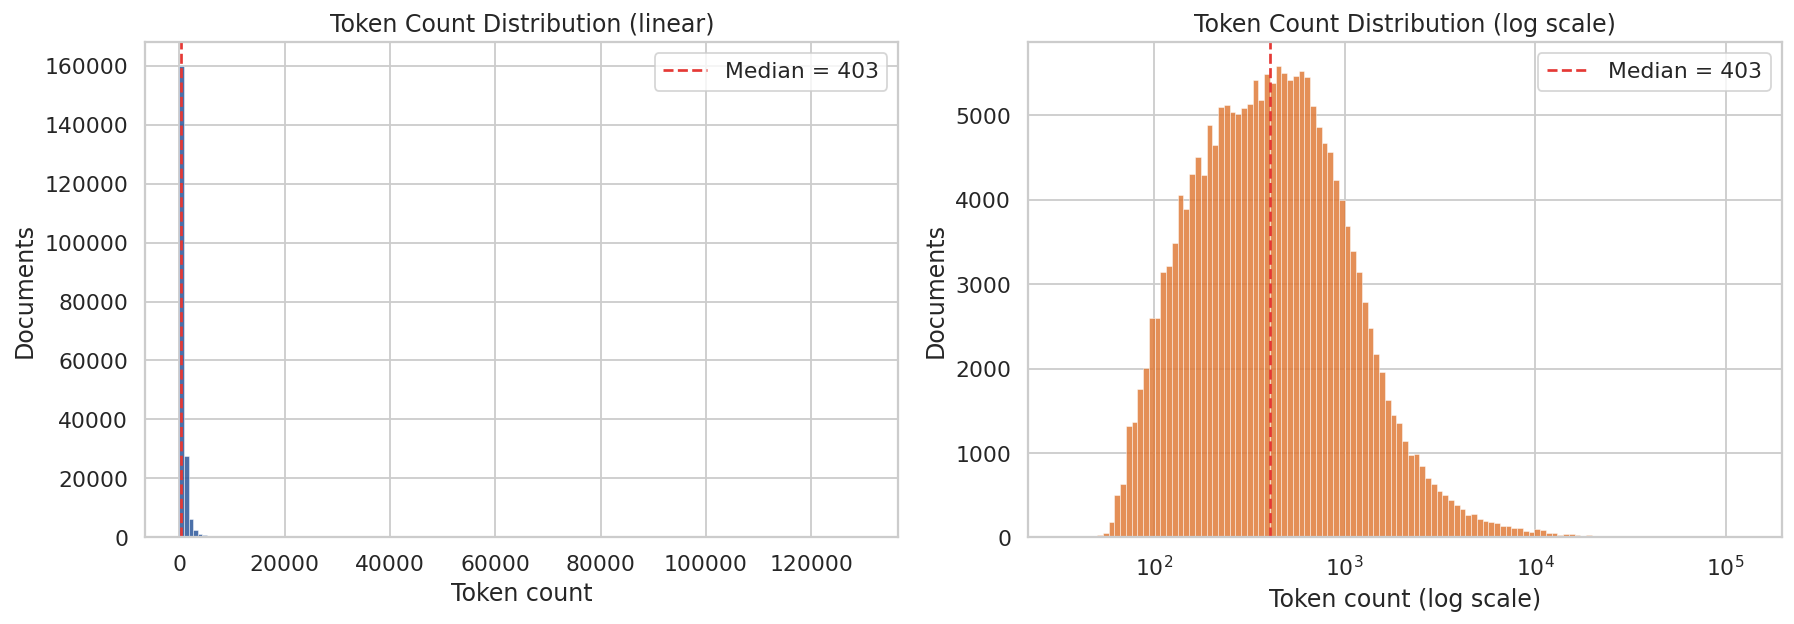

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Linear scale ──
med = df_meta["token_count"].median()
axes[0].hist(df_meta["token_count"], bins=150, color=C["blue"],
             alpha=0.85, edgecolor="white", linewidth=0.3)
axes[0].axvline(med, color=C["red"], ls="--", lw=1.5,
                label=f"Median = {med:.0f}")
axes[0].set_xlabel("Token count")
axes[0].set_ylabel("Documents")
axes[0].set_title("Token Count Distribution (linear)")
axes[0].legend()

# ── Log scale ──
bins_log = np.logspace(
    np.log10(max(1, df_meta["token_count"].min())),
    np.log10(df_meta["token_count"].max()),
    120,
)
axes[1].hist(df_meta["token_count"], bins=bins_log,
             color=C["orange"], alpha=0.85, edgecolor="white", linewidth=0.3)
axes[1].set_xscale("log")
axes[1].axvline(med, color=C["red"], ls="--", lw=1.5,
                label=f"Median = {med:.0f}")
axes[1].set_xlabel("Token count (log scale)")
axes[1].set_ylabel("Documents")
axes[1].set_title("Token Count Distribution (log scale)")
axes[1].legend()

plt.tight_layout()
plt.savefig("01_token_distribution.png", bbox_inches="tight")
plt.show()

**Observation:** The distribution is heavily right-skewed. Most documents are short (< 500 tokens), but a long tail extends to several thousand. The log-scale histogram reveals a roughly log-normal shape, consistent with the heterogeneous nature of web content.

---
## 5 · Language Score Distribution

FineWeb uses a **fastText** classifier to detect English content, keeping only documents with a score ≥ 0.65.

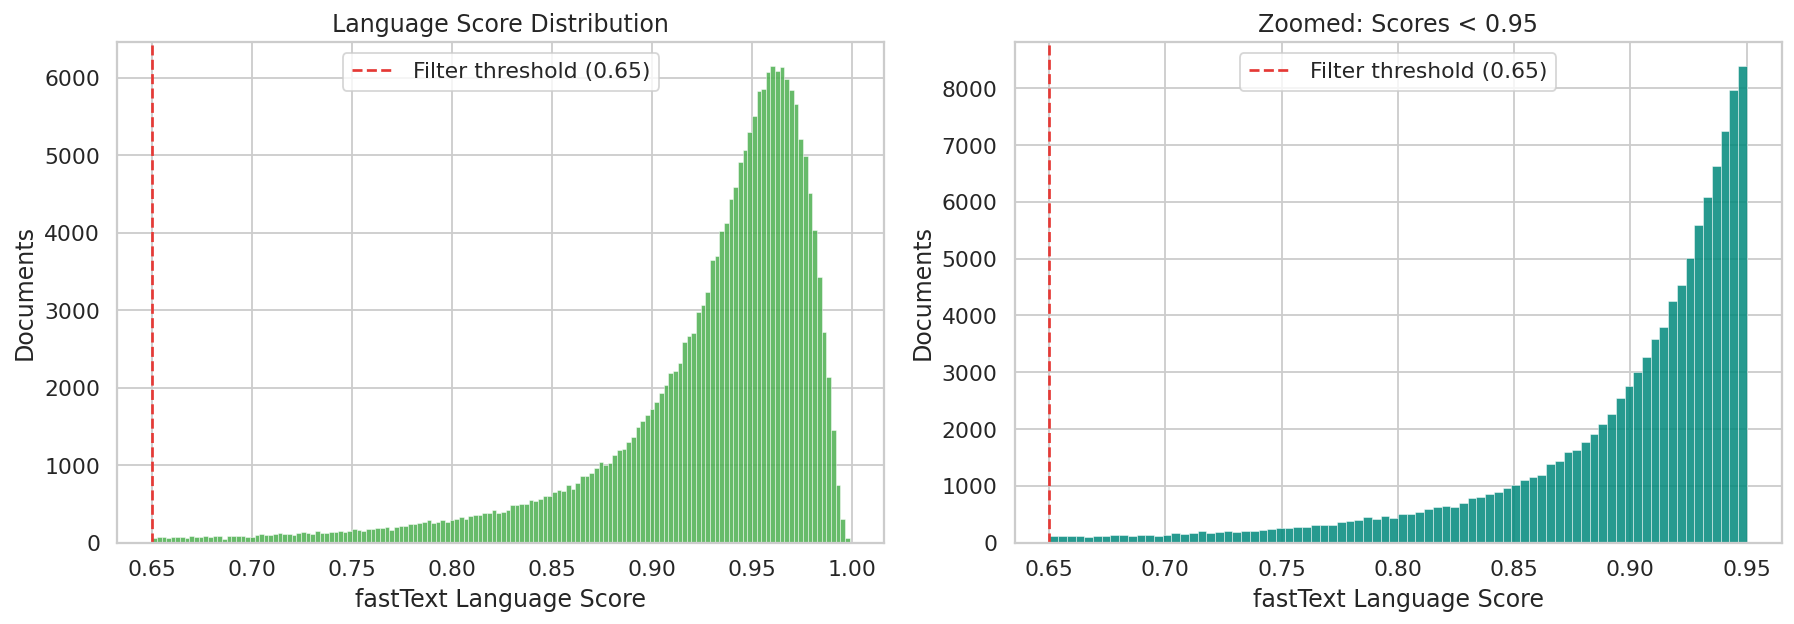

  Score ≥ 0.9: 79.59%
  Score ≥ 0.95: 44.43%
  Score ≥ 0.99: 1.13%


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Full distribution ──
axes[0].hist(df_meta["language_score"], bins=150,
             color=C["green"], alpha=0.85, edgecolor="white", linewidth=0.3)
axes[0].axvline(0.65, color=C["red"], ls="--", lw=1.5,
                label="Filter threshold (0.65)")
axes[0].set_xlabel("fastText Language Score")
axes[0].set_ylabel("Documents")
axes[0].set_title("Language Score Distribution")
axes[0].legend()

# ── Zoomed: below 0.95 ──
low_score = df_meta[df_meta["language_score"] < 0.95]["language_score"]
axes[1].hist(low_score, bins=80,
             color=C["teal"], alpha=0.85, edgecolor="white", linewidth=0.3)
axes[1].axvline(0.65, color=C["red"], ls="--", lw=1.5,
                label="Filter threshold (0.65)")
axes[1].set_xlabel("fastText Language Score")
axes[1].set_ylabel("Documents")
axes[1].set_title("Zoomed: Scores < 0.95")
axes[1].legend()

plt.tight_layout()
plt.savefig("02_language_score.png", bbox_inches="tight")
plt.show()

for t in [0.9, 0.95, 0.99]:
    frac = (df_meta["language_score"] >= t).mean()
    print(f"  Score ≥ {t}: {frac:.2%}")

**Observation:** The vast majority of documents cluster near 1.0, confirming effective English filtering. The zoomed view reveals a non-trivial tail below 0.95 — these may be code-heavy, multilingual, or low-quality pages that passed the 0.65 threshold.

---
## 6 · Document Length Distributions (Characters & Words)

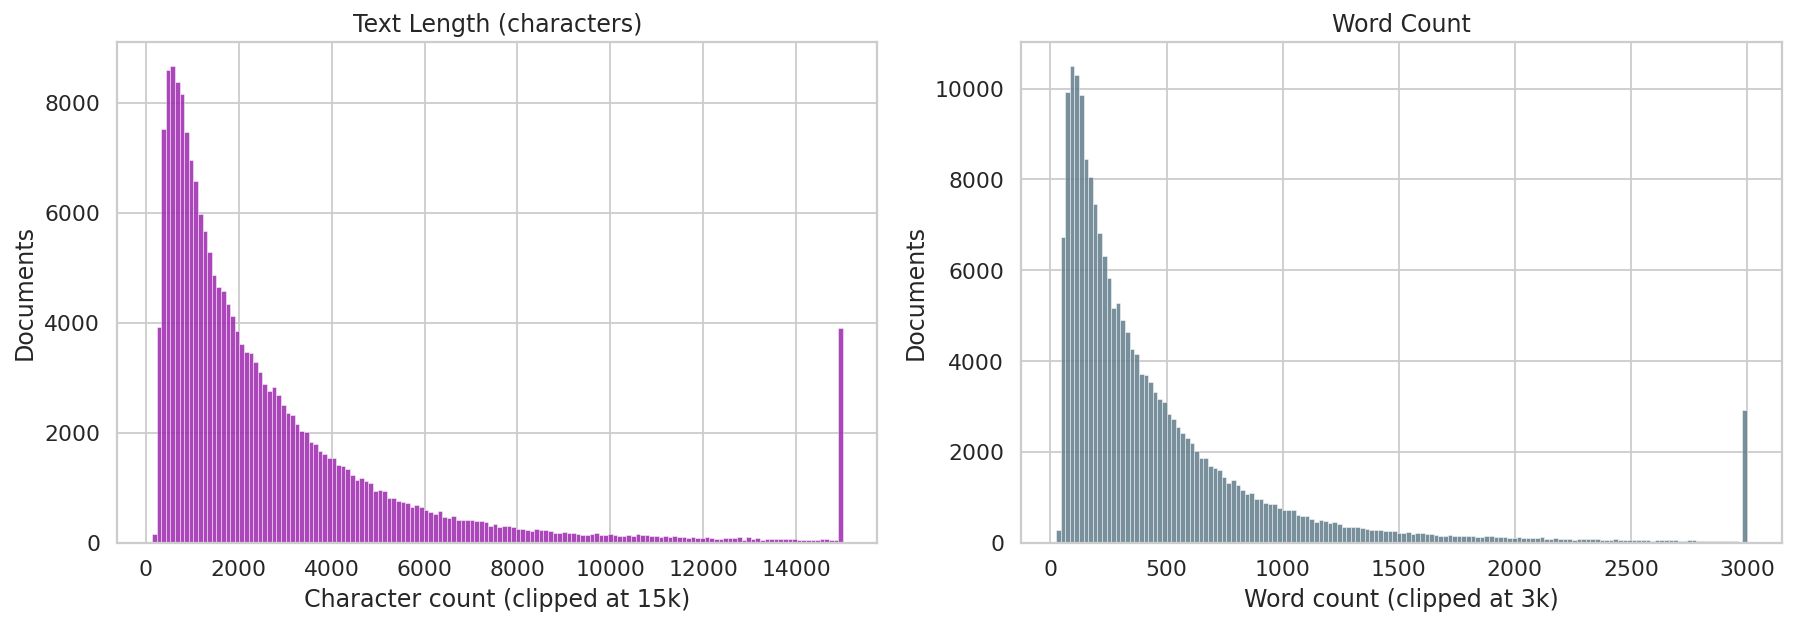

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_meta["text_length"].clip(upper=15000), bins=150,
             color=C["purple"], alpha=0.85, edgecolor="white", linewidth=0.3)
axes[0].set_xlabel("Character count (clipped at 15k)")
axes[0].set_ylabel("Documents")
axes[0].set_title("Text Length (characters)")

axes[1].hist(df_meta["word_count"].clip(upper=3000), bins=150,
             color=C["grey"], alpha=0.85, edgecolor="white", linewidth=0.3)
axes[1].set_xlabel("Word count (clipped at 3k)")
axes[1].set_ylabel("Documents")
axes[1].set_title("Word Count")

plt.tight_layout()
plt.savefig("03_text_lengths.png", bbox_inches="tight")
plt.show()

---
## 7 · Token Count vs Language Score (2D Density)

Do longer documents tend to have higher or lower language confidence?

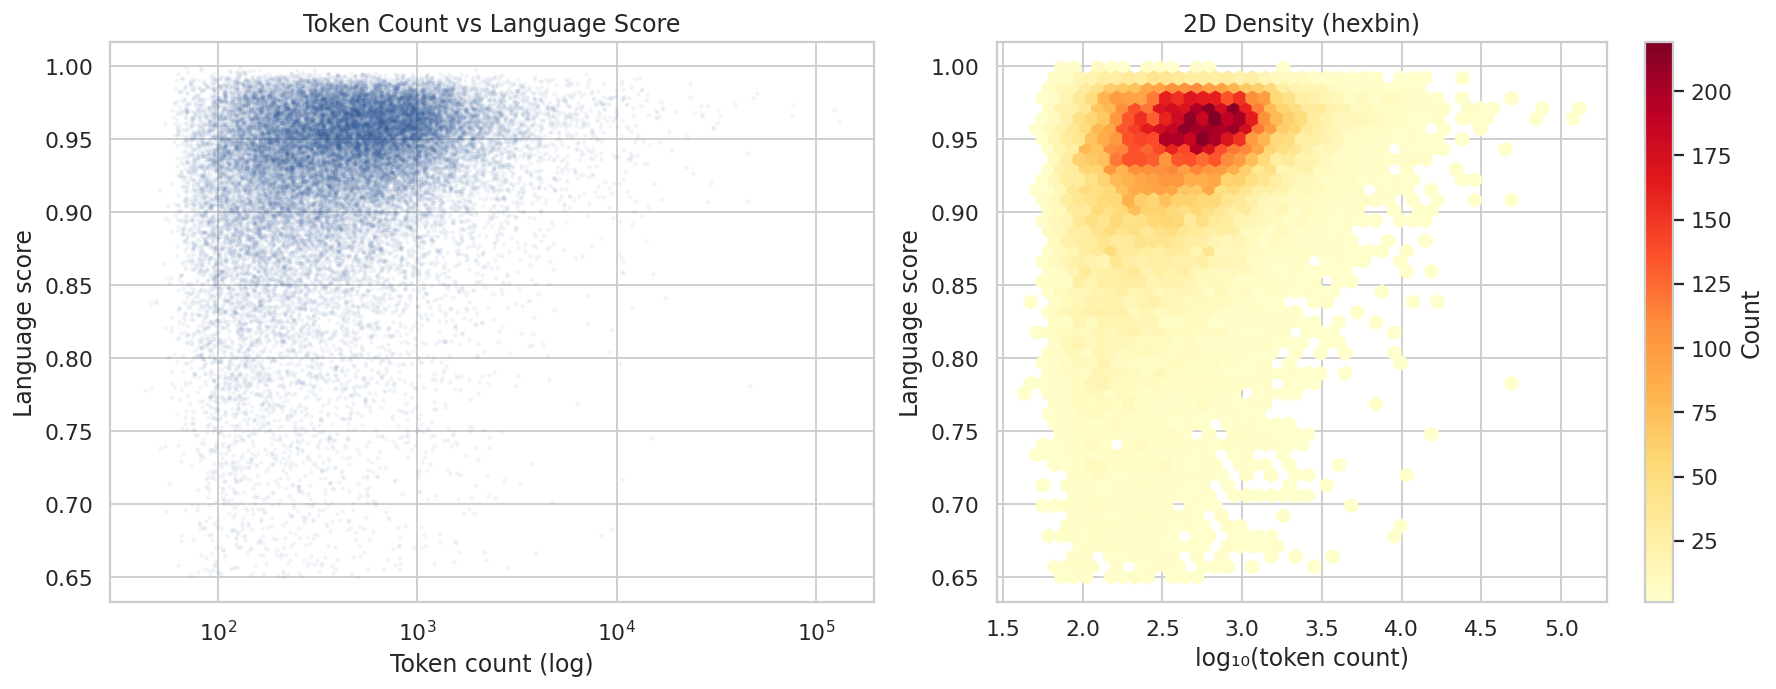

In [12]:
plot_sample = df_meta.sample(min(30_000, len(df_meta)), random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# ── Scatter ──
axes[0].scatter(
    plot_sample["token_count"],
    plot_sample["language_score"],
    alpha=0.04, s=3, c=C["blue"], rasterized=True,
)
axes[0].set_xscale("log")
axes[0].set_xlabel("Token count (log)")
axes[0].set_ylabel("Language score")
axes[0].set_title("Token Count vs Language Score")

# ── 2D hexbin density ──
hb = axes[1].hexbin(
    np.log10(plot_sample["token_count"].clip(lower=1)),
    plot_sample["language_score"],
    gridsize=45, cmap="YlOrRd", mincnt=1,
)
axes[1].set_xlabel("log₁₀(token count)")
axes[1].set_ylabel("Language score")
axes[1].set_title("2D Density (hexbin)")
plt.colorbar(hb, ax=axes[1], label="Count")

plt.tight_layout()
plt.savefig("04_scatter_tokens_lang.png", bbox_inches="tight")
plt.show()

**Observation:** The density is concentrated at high language scores (> 0.95) across all document lengths. However, very short documents show slightly more variance in language score — shorter text gives the classifier less signal.

---
## 8 · Temporal Analysis — Documents per Common Crawl Dump

FineWeb spans 96 CC snapshots. How are documents distributed across them?

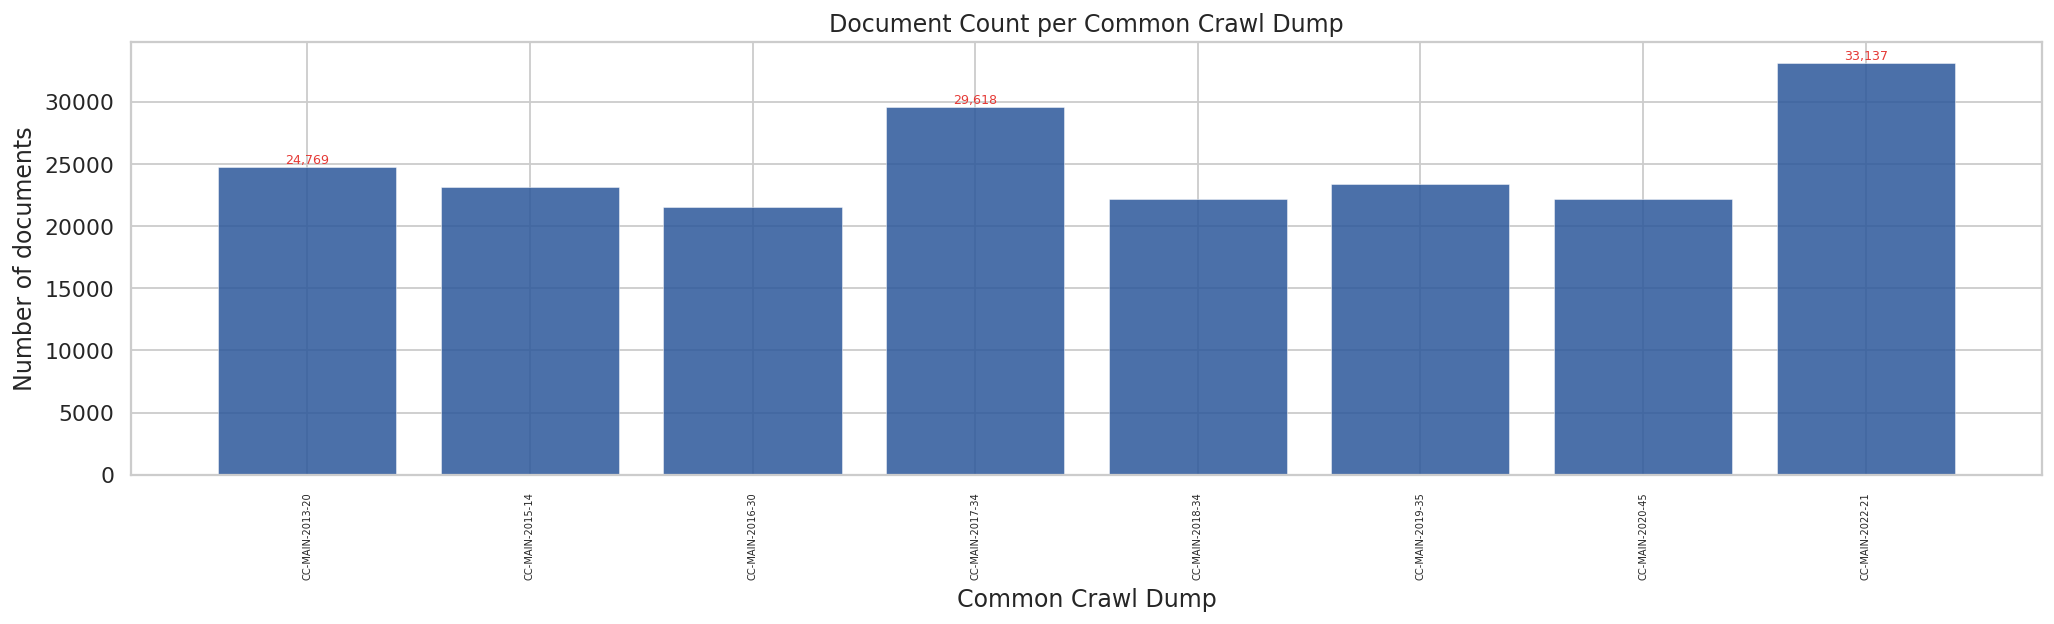

Total dumps: 8


In [13]:
dump_counts = df_meta["dump"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(16, 5))
bars = ax.bar(range(len(dump_counts)), dump_counts.values,
              color=C["blue"], alpha=0.85, edgecolor="white", linewidth=0.3)
ax.set_xticks(range(len(dump_counts)))
ax.set_xticklabels(dump_counts.index, rotation=90, fontsize=5.5)
ax.set_xlabel("Common Crawl Dump")
ax.set_ylabel("Number of documents")
ax.set_title("Document Count per Common Crawl Dump")

# Annotate top 3
for idx in dump_counts.nlargest(3).index:
    pos = list(dump_counts.index).index(idx)
    ax.annotate(f"{dump_counts[idx]:,}",
                xy=(pos, dump_counts[idx]),
                ha="center", va="bottom", fontsize=7, color=C["red"])

plt.tight_layout()
plt.savefig("05_docs_per_dump.png", bbox_inches="tight")
plt.show()

print(f"Total dumps: {len(dump_counts)}")

---
## 9 · Temporal Analysis — Token Volume per Dump

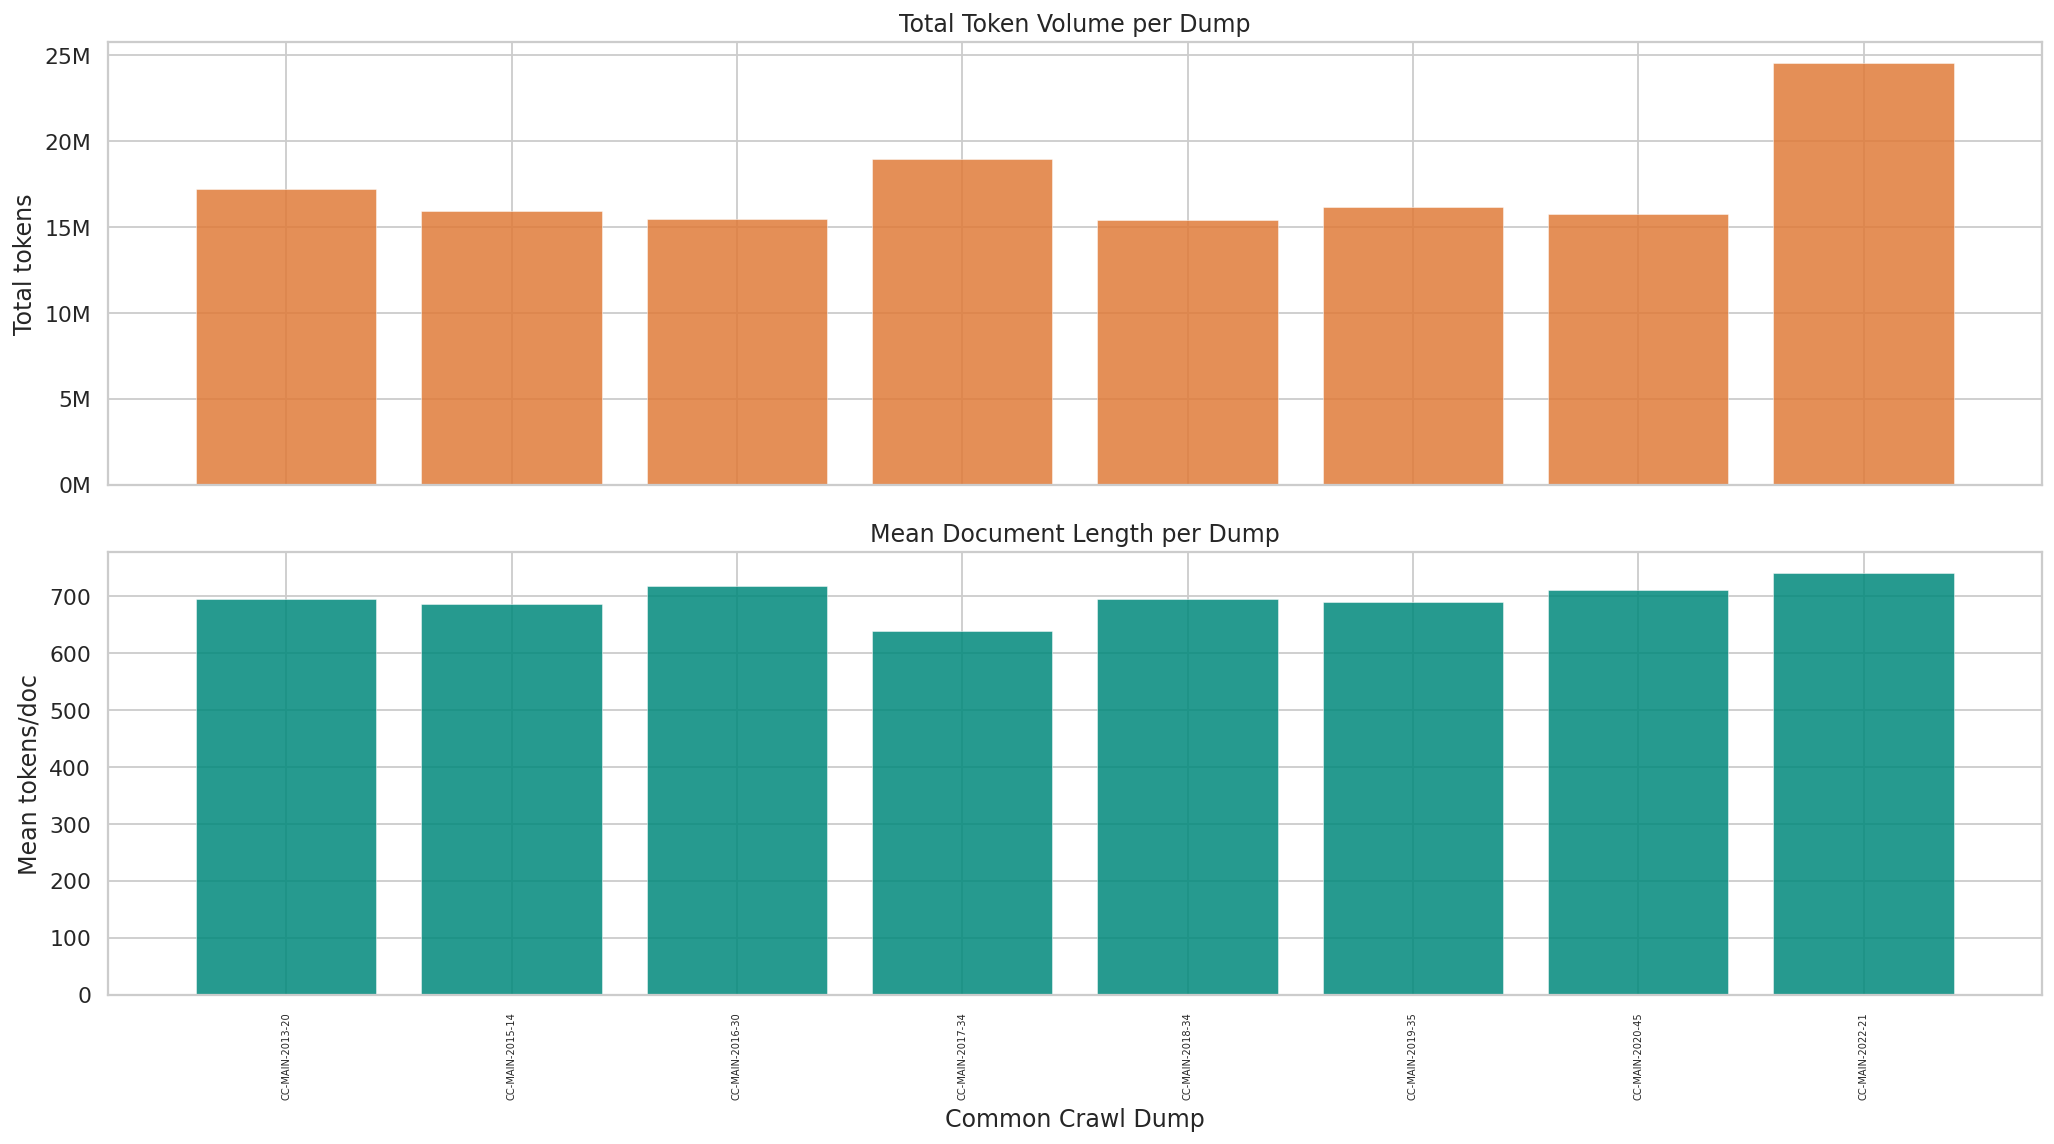

In [14]:
tokens_per_dump = df_meta.groupby("dump")["token_count"].sum().sort_index()
mean_tokens_per_dump = df_meta.groupby("dump")["token_count"].mean().sort_index()

fig, axes = plt.subplots(2, 1, figsize=(16, 9), sharex=True)

# Total tokens
axes[0].bar(range(len(tokens_per_dump)), tokens_per_dump.values,
            color=C["orange"], alpha=0.85, edgecolor="white", linewidth=0.3)
axes[0].set_ylabel("Total tokens")
axes[0].set_title("Total Token Volume per Dump")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.0f}M"))

# Mean tokens per document
axes[1].bar(range(len(mean_tokens_per_dump)), mean_tokens_per_dump.values,
            color=C["teal"], alpha=0.85, edgecolor="white", linewidth=0.3)
axes[1].set_xticks(range(len(tokens_per_dump)))
axes[1].set_xticklabels(tokens_per_dump.index, rotation=90, fontsize=5.5)
axes[1].set_xlabel("Common Crawl Dump")
axes[1].set_ylabel("Mean tokens/doc")
axes[1].set_title("Mean Document Length per Dump")

plt.tight_layout()
plt.savefig("06_tokens_per_dump.png", bbox_inches="tight")
plt.show()

---
## 10 · Temporal Analysis — Yearly Trends

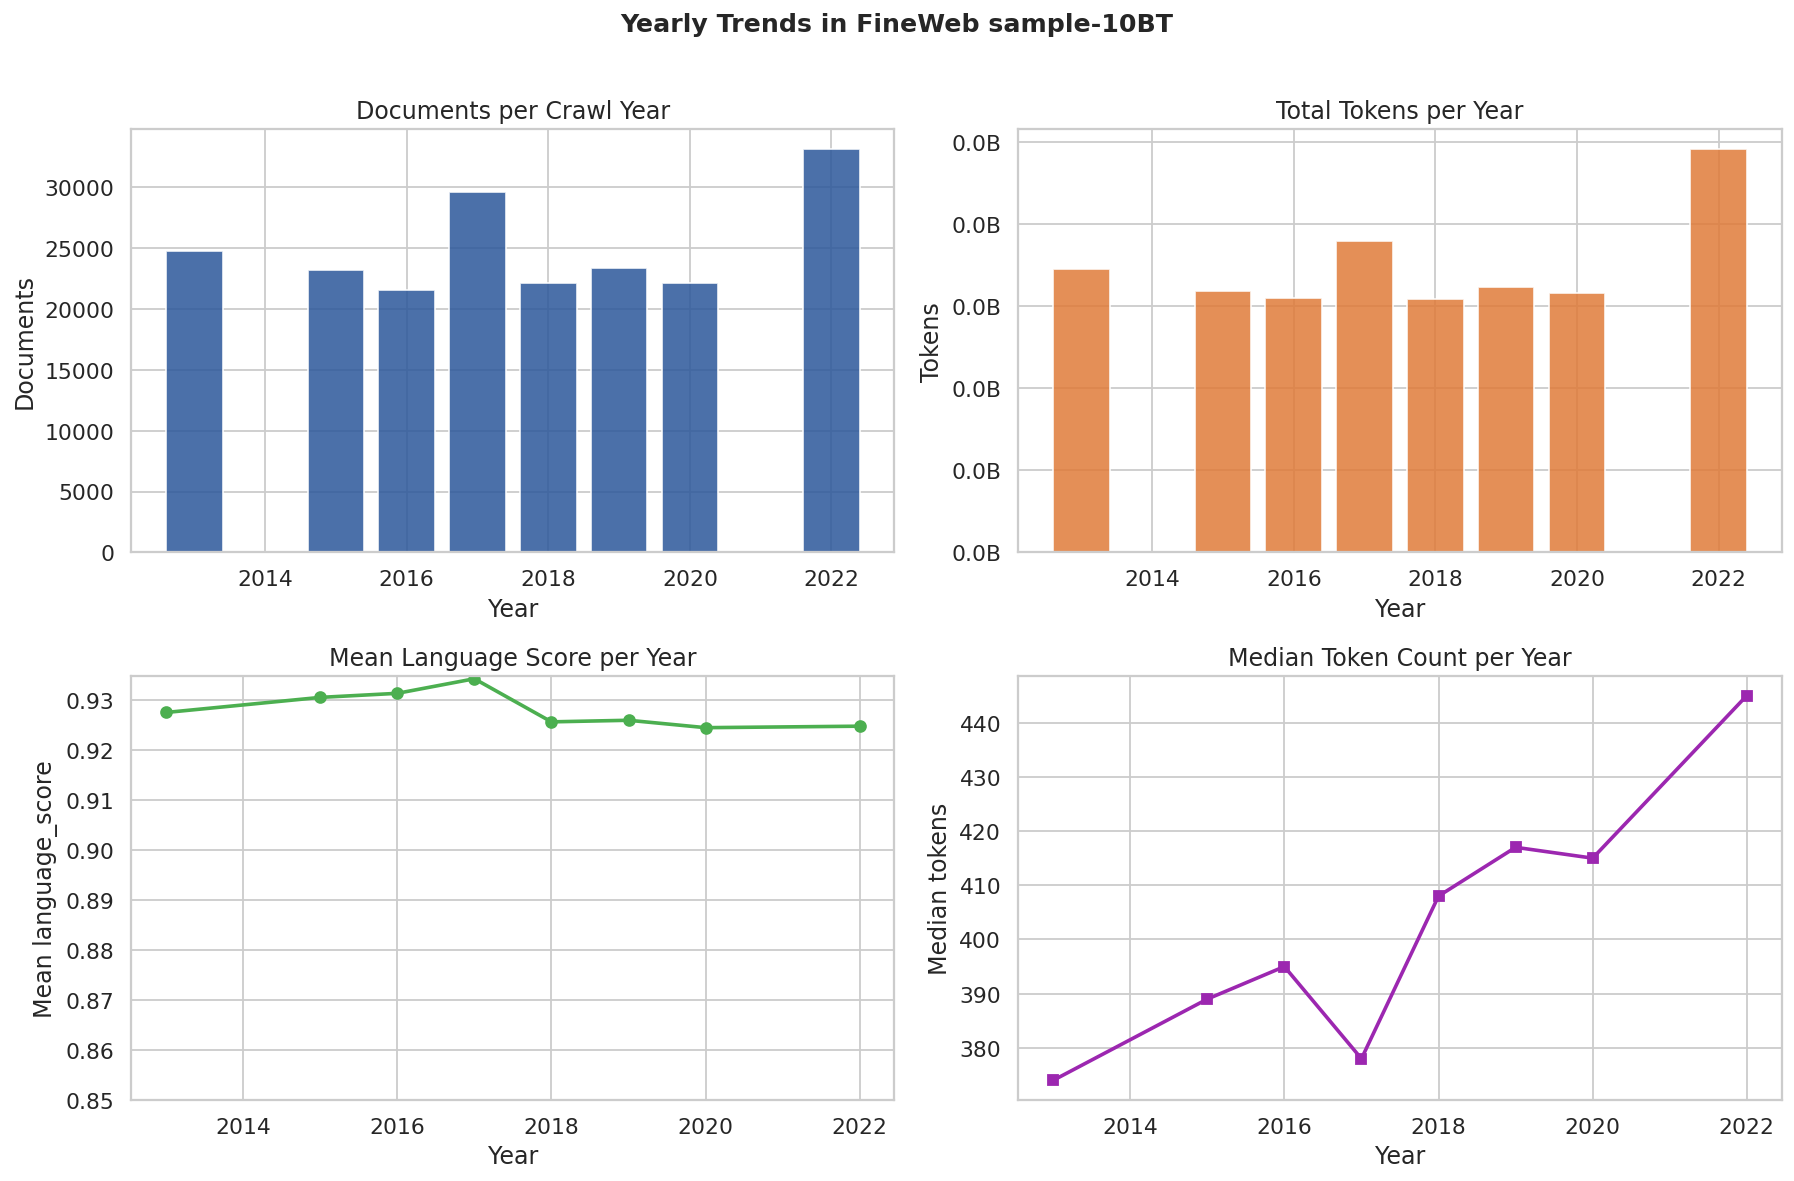

In [15]:
yearly_docs   = df_meta["crawl_year"].value_counts().sort_index()
yearly_tokens  = df_meta.groupby("crawl_year")["token_count"].sum().sort_index()
yearly_lang    = df_meta.groupby("crawl_year")["language_score"].mean().sort_index()
yearly_med_tok = df_meta.groupby("crawl_year")["token_count"].median().sort_index()

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# (a) Documents per year
axes[0, 0].bar(yearly_docs.index.astype(int), yearly_docs.values,
               color=C["blue"], alpha=0.85)
axes[0, 0].set_title("Documents per Crawl Year")
axes[0, 0].set_xlabel("Year")
axes[0, 0].set_ylabel("Documents")

# (b) Total tokens per year
axes[0, 1].bar(yearly_tokens.index.astype(int), yearly_tokens.values,
               color=C["orange"], alpha=0.85)
axes[0, 1].set_title("Total Tokens per Year")
axes[0, 1].set_xlabel("Year")
axes[0, 1].set_ylabel("Tokens")
axes[0, 1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e9:.1f}B"))

# (c) Mean language score per year
axes[1, 0].plot(yearly_lang.index.astype(int), yearly_lang.values,
                marker="o", color=C["green"], lw=2)
axes[1, 0].set_title("Mean Language Score per Year")
axes[1, 0].set_xlabel("Year")
axes[1, 0].set_ylabel("Mean language_score")
axes[1, 0].set_ylim(bottom=0.85)

# (d) Median token count per year
axes[1, 1].plot(yearly_med_tok.index.astype(int), yearly_med_tok.values,
                marker="s", color=C["purple"], lw=2)
axes[1, 1].set_title("Median Token Count per Year")
axes[1, 1].set_xlabel("Year")
axes[1, 1].set_ylabel("Median tokens")

plt.suptitle("Yearly Trends in FineWeb sample-10BT", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("07_yearly_trends.png", bbox_inches="tight")
plt.show()

**Observation:** More recent years contribute more documents (the web grows over time, and more snapshots exist). Tracking the mean language score and median document length over time reveals whether web content quality or structure has shifted.

---
## 11 · Domain Analysis — Top 30 Domains

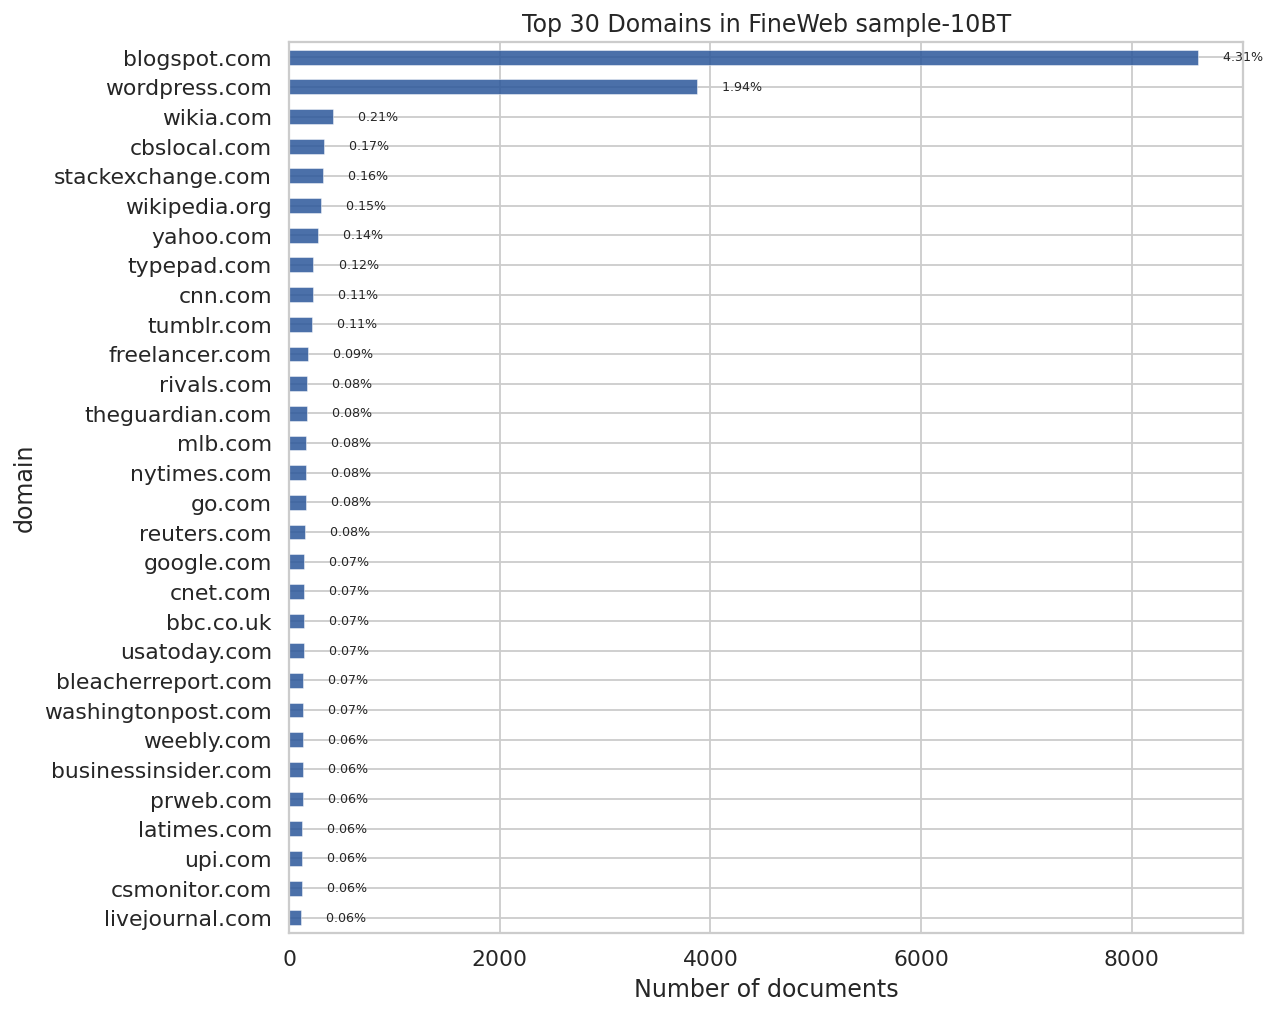

Unique domains: 115,085
Top 30 cover: 8.83% of all documents
Top 100 cover:  11.52%
Top 1000 cover: 22.66%


In [16]:
top_n = 30
domain_counts = df_meta["domain"].value_counts()
top_domains = domain_counts.head(top_n)

fig, ax = plt.subplots(figsize=(10, 8))
top_domains.sort_values().plot(
    kind="barh", ax=ax, color=C["blue"], alpha=0.85,
    edgecolor="white", linewidth=0.3,
)
ax.set_xlabel("Number of documents")
ax.set_title(f"Top {top_n} Domains in FineWeb sample-10BT")

# Add percentages
total = len(df_meta)
for i, (val, name) in enumerate(zip(top_domains.sort_values().values,
                                     top_domains.sort_values().index)):
    ax.text(val + total * 0.001, i, f" {val/total:.2%}", va="center", fontsize=7)

plt.tight_layout()
plt.savefig("08_top_domains.png", bbox_inches="tight")
plt.show()

print(f"Unique domains: {domain_counts.shape[0]:,}")
print(f"Top {top_n} cover: {top_domains.sum()/total:.2%} of all documents")
print(f"Top 100 cover:  {domain_counts.head(100).sum()/total:.2%}")
print(f"Top 1000 cover: {domain_counts.head(1000).sum()/total:.2%}")

---
## 12 · Domain Concentration — Lorenz Curve

How concentrated is the domain distribution? The Lorenz curve shows inequality.

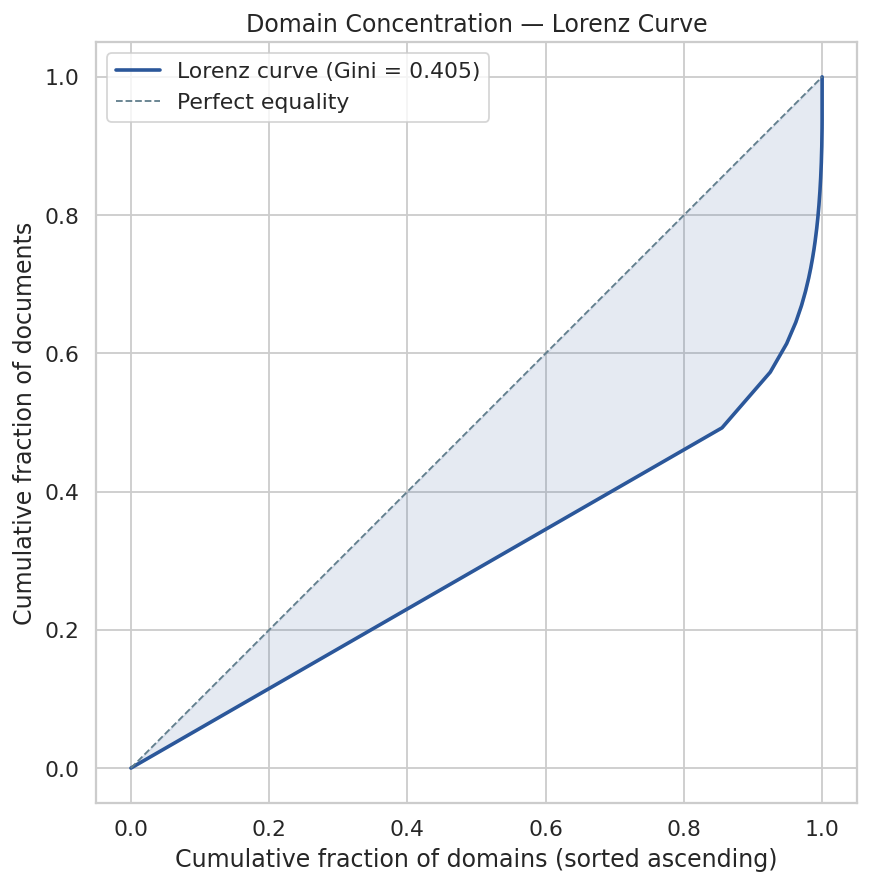

Gini coefficient: 0.4047
(1.0 = one domain has all docs, 0.0 = perfectly uniform)


In [17]:
sorted_counts = np.sort(domain_counts.values)
cumulative = np.cumsum(sorted_counts) / sorted_counts.sum()
n = len(sorted_counts)
x = np.arange(1, n + 1) / n

# Gini coefficient
gini = 1 - 2 * np.trapz(cumulative, x)

fig, ax = plt.subplots(figsize=(7, 7))
ax.plot(x, cumulative, color=C["blue"], lw=2, label=f"Lorenz curve (Gini = {gini:.3f})")
ax.plot([0, 1], [0, 1], "--", color=C["grey"], lw=1, label="Perfect equality")
ax.fill_between(x, cumulative, x, alpha=0.12, color=C["blue"])
ax.set_xlabel("Cumulative fraction of domains (sorted ascending)")
ax.set_ylabel("Cumulative fraction of documents")
ax.set_title("Domain Concentration — Lorenz Curve")
ax.legend(loc="upper left")
ax.set_aspect("equal")

plt.tight_layout()
plt.savefig("09_lorenz_domains.png", bbox_inches="tight")
plt.show()

print(f"Gini coefficient: {gini:.4f}")
print(f"(1.0 = one domain has all docs, 0.0 = perfectly uniform)")

---
## 13 · TLD (Top-Level Domain) Breakdown

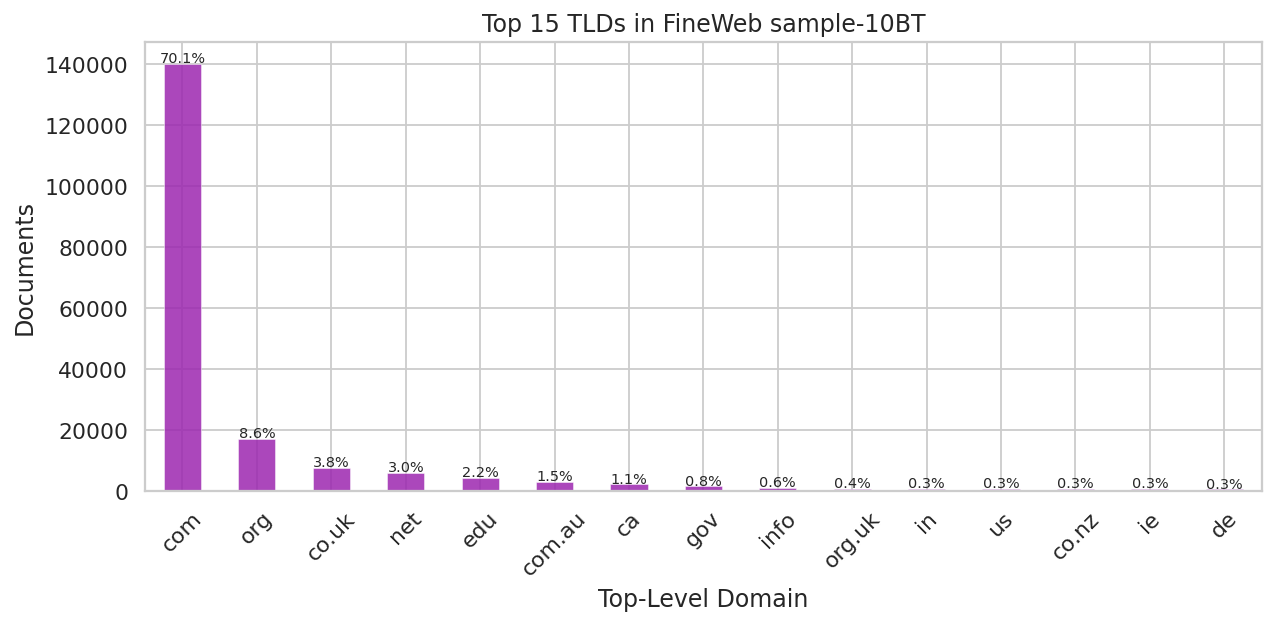

In [18]:
df_meta["tld"] = df_meta["url"].apply(
    lambda u: tldextract.extract(u).suffix
)

tld_counts = df_meta["tld"].value_counts().head(15)

fig, ax = plt.subplots(figsize=(10, 5))
tld_counts.plot(kind="bar", ax=ax, color=C["purple"], alpha=0.85,
                edgecolor="white", linewidth=0.3)
ax.set_xlabel("Top-Level Domain")
ax.set_ylabel("Documents")
ax.set_title("Top 15 TLDs in FineWeb sample-10BT")
ax.tick_params(axis="x", rotation=45)

# Percentage labels
for i, v in enumerate(tld_counts.values):
    ax.text(i, v + total * 0.002, f"{v/total:.1%}", ha="center", fontsize=8)

plt.tight_layout()
plt.savefig("10_tld_breakdown.png", bbox_inches="tight")
plt.show()

---
## 14 · Quality Metrics by Domain

Do some domains produce longer or higher-confidence documents?

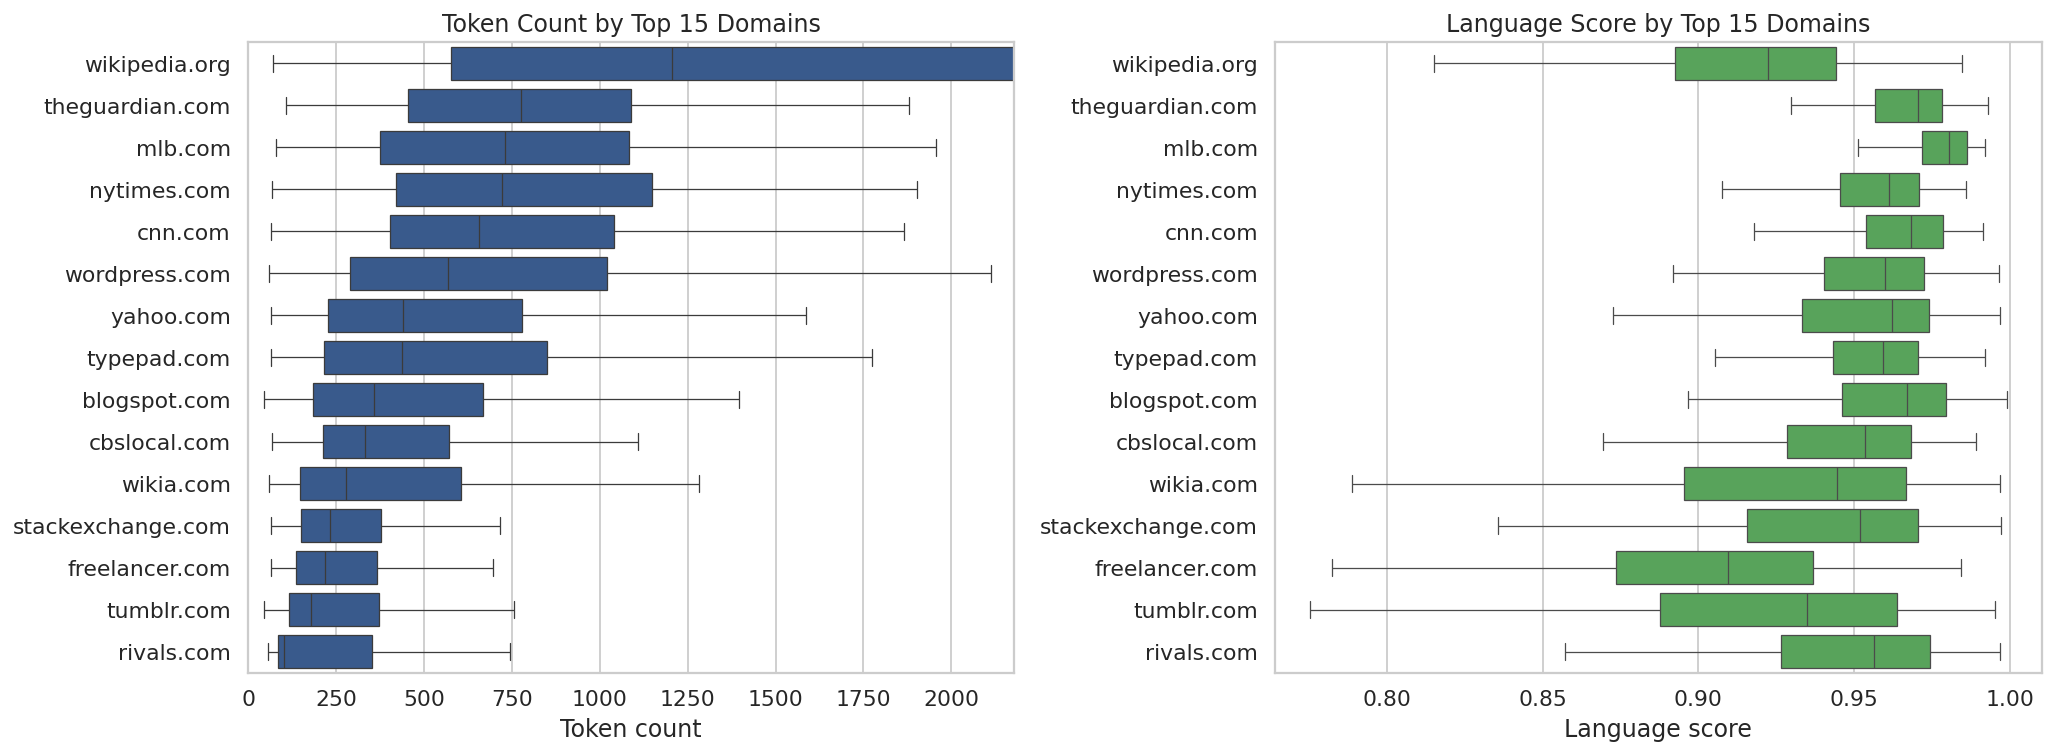

In [19]:
top15_domains = df_meta["domain"].value_counts().head(15).index
df_top = df_meta[df_meta["domain"].isin(top15_domains)].copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Token count per domain ──
order = (df_top.groupby("domain")["token_count"].median()
         .sort_values(ascending=False).index)
sns.boxplot(
    data=df_top, y="domain", x="token_count", order=order,
    ax=axes[0], color=C["blue"], fliersize=1, linewidth=0.7,
    showfliers=False,
)
axes[0].set_xlabel("Token count")
axes[0].set_ylabel("")
axes[0].set_title("Token Count by Top 15 Domains")
axes[0].set_xlim(0, df_top["token_count"].quantile(0.95))

# ── Language score per domain ──
sns.boxplot(
    data=df_top, y="domain", x="language_score", order=order,
    ax=axes[1], color=C["green"], fliersize=1, linewidth=0.7,
    showfliers=False,
)
axes[1].set_xlabel("Language score")
axes[1].set_ylabel("")
axes[1].set_title("Language Score by Top 15 Domains")

plt.tight_layout()
plt.savefig("11_quality_by_domain.png", bbox_inches="tight")
plt.show()

---
## 15 · Correlation Heatmap

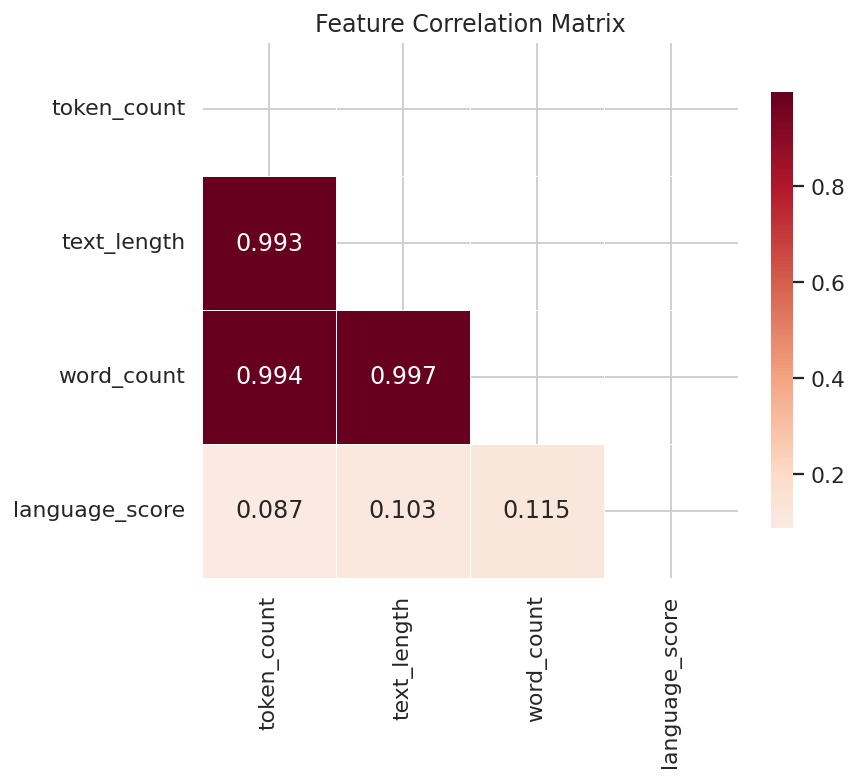

In [20]:
corr_cols = ["token_count", "text_length", "word_count", "language_score"]
corr = df_meta[corr_cols].corr()

fig, ax = plt.subplots(figsize=(7, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt=".3f", cmap="RdBu_r", center=0,
            mask=mask, ax=ax, square=True, linewidths=0.5,
            cbar_kws={"shrink": 0.8})
ax.set_title("Feature Correlation Matrix")
plt.tight_layout()
plt.savefig("12_correlation.png", bbox_inches="tight")
plt.show()

**Observation:** Token count, text length, and word count are near-perfectly correlated (they measure the same underlying quantity — document size — with different units). Language score shows a weak positive correlation with length.

---
## 16 · Distribution of Documents Across Quality Bins

We bin documents by language score and token count to create a 2D heatmap of the quality landscape.

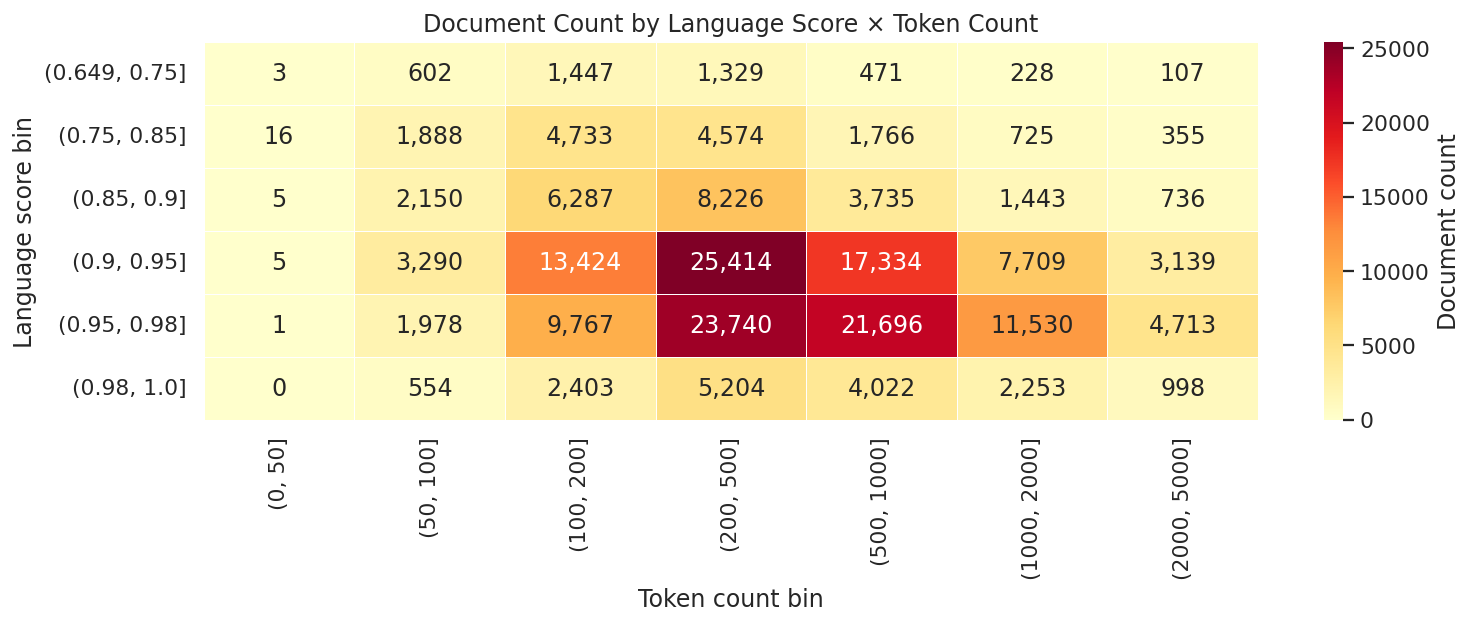

In [21]:
df_meta["lang_bin"] = pd.cut(
    df_meta["language_score"],
    bins=[0.65, 0.75, 0.85, 0.90, 0.95, 0.98, 1.0],
    include_lowest=True,
)
df_meta["tok_bin"] = pd.cut(
    df_meta["token_count"].clip(upper=5000),
    bins=[0, 50, 100, 200, 500, 1000, 2000, 5000],
)

pivot = df_meta.groupby(["lang_bin", "tok_bin"]).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(
    pivot, annot=True, fmt=",", cmap="YlOrRd", ax=ax,
    linewidths=0.5, cbar_kws={"label": "Document count"},
)
ax.set_xlabel("Token count bin")
ax.set_ylabel("Language score bin")
ax.set_title("Document Count by Language Score × Token Count")
plt.tight_layout()
plt.savefig("13_quality_heatmap.png", bbox_inches="tight")
plt.show()

---
## 17 · Token Count Distribution by Crawl Year (Violin Plot)

How does the distribution of document lengths change across years?

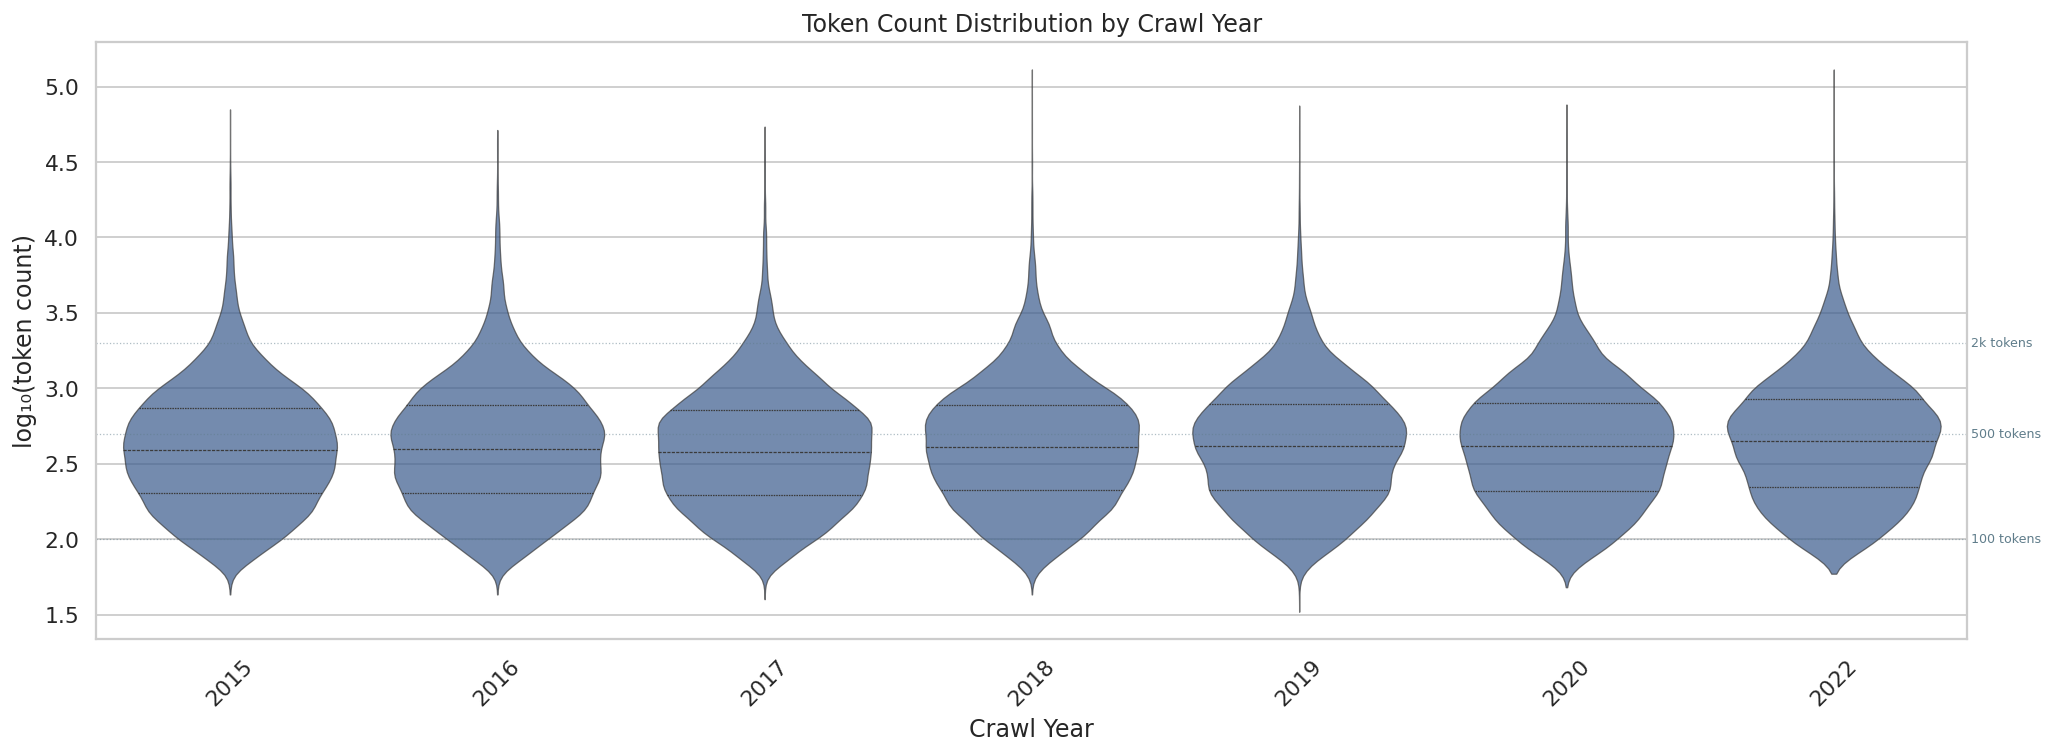

In [22]:
valid_years = df_meta.dropna(subset=["crawl_year"])
valid_years = valid_years[valid_years["crawl_year"] >= 2014]
valid_years["crawl_year"] = valid_years["crawl_year"].astype(int)

fig, ax = plt.subplots(figsize=(16, 6))
sns.violinplot(
    data=valid_years, x="crawl_year",
    y=np.log10(valid_years["token_count"].clip(lower=1)),
    ax=ax, color=C["blue"], alpha=0.7, inner="quartile",
    linewidth=0.7, cut=0, density_norm="width",
)
ax.set_xlabel("Crawl Year")
ax.set_ylabel("log₁₀(token count)")
ax.set_title("Token Count Distribution by Crawl Year")
ax.tick_params(axis="x", rotation=45)

# Add reference lines
for val, label in [(np.log10(100), "100"), (np.log10(500), "500"),
                    (np.log10(2000), "2k")]:
    ax.axhline(val, color=C["grey"], ls=":", lw=0.7, alpha=0.5)
    ax.text(ax.get_xlim()[1], val, f" {label} tokens", va="center",
            fontsize=7, color=C["grey"])

plt.tight_layout()
plt.savefig("14_violin_year.png", bbox_inches="tight")
plt.show()

---
## 18 · Filtering Pipeline Funnel (Estimated)

Based on the FineWeb paper (Penedo et al., NeurIPS 2024), the pipeline reduces data at each stage.  
We visualize the approximate token counts surviving each step.

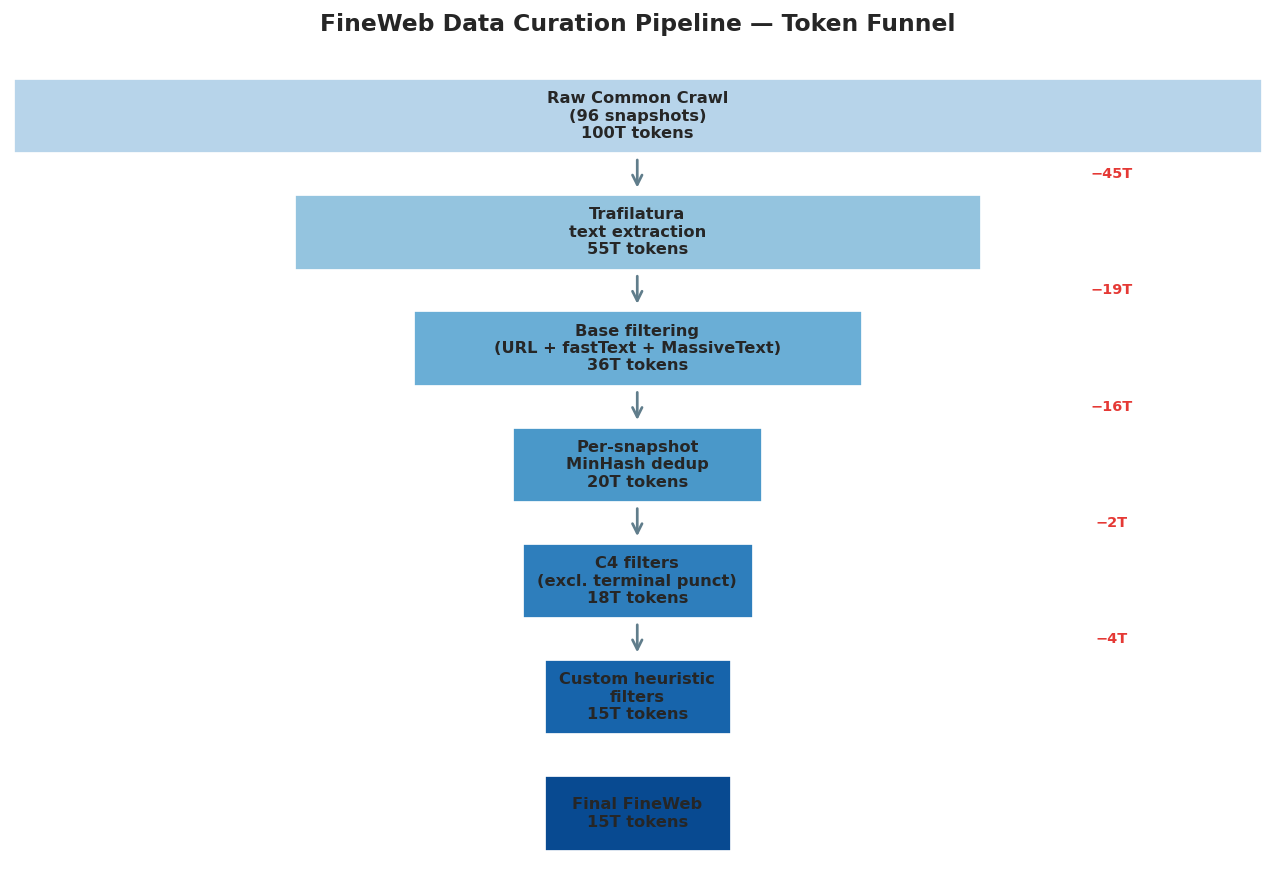

In [23]:
# Approximate figures from the paper
stages = [
    "Raw Common Crawl\n(96 snapshots)",
    "Trafilatura\ntext extraction",
    "Base filtering\n(URL + fastText + MassiveText)",
    "Per-snapshot\nMinHash dedup",
    "C4 filters\n(excl. terminal punct)",
    "Custom heuristic\nfilters",
    "Final FineWeb",
]
# Estimated trillion tokens at each stage
tokens_T = [100, 55, 36, 20, 18.5, 15, 15]

fig, ax = plt.subplots(figsize=(10, 7))

colors = plt.cm.Blues(np.linspace(0.3, 0.9, len(stages)))
y_positions = np.arange(len(stages))[::-1]

max_width = max(tokens_T)
for i, (stage, tok, y) in enumerate(zip(stages, tokens_T, y_positions)):
    width = tok / max_width
    bar = ax.barh(y, width, height=0.65, left=(1 - width) / 2,
                  color=colors[i], edgecolor="white", linewidth=1.5)
    ax.text(0.5, y, f"{stage}\n{tok:.0f}T tokens",
            ha="center", va="center", fontsize=9, fontweight="bold")

ax.set_xlim(0, 1)
ax.set_ylim(-0.5, len(stages) - 0.5)
ax.axis("off")
ax.set_title("FineWeb Data Curation Pipeline — Token Funnel",
             fontsize=13, fontweight="bold", pad=15)

# Add arrows
for i in range(len(stages) - 1):
    y_top = y_positions[i]
    y_bot = y_positions[i + 1]
    removed = tokens_T[i] - tokens_T[i + 1]
    if removed > 0:
        ax.annotate("", xy=(0.5, y_bot + 0.35), xytext=(0.5, y_top - 0.35),
                    arrowprops=dict(arrowstyle="->", color=C["grey"], lw=1.5))
        ax.text(0.88, (y_top + y_bot) / 2, f"−{removed:.0f}T",
                ha="center", va="center", fontsize=8, color=C["red"],
                fontweight="bold")

plt.tight_layout()
plt.savefig("15_pipeline_funnel.png", bbox_inches="tight")
plt.show()

---
## 19 · Word Cloud of Domains

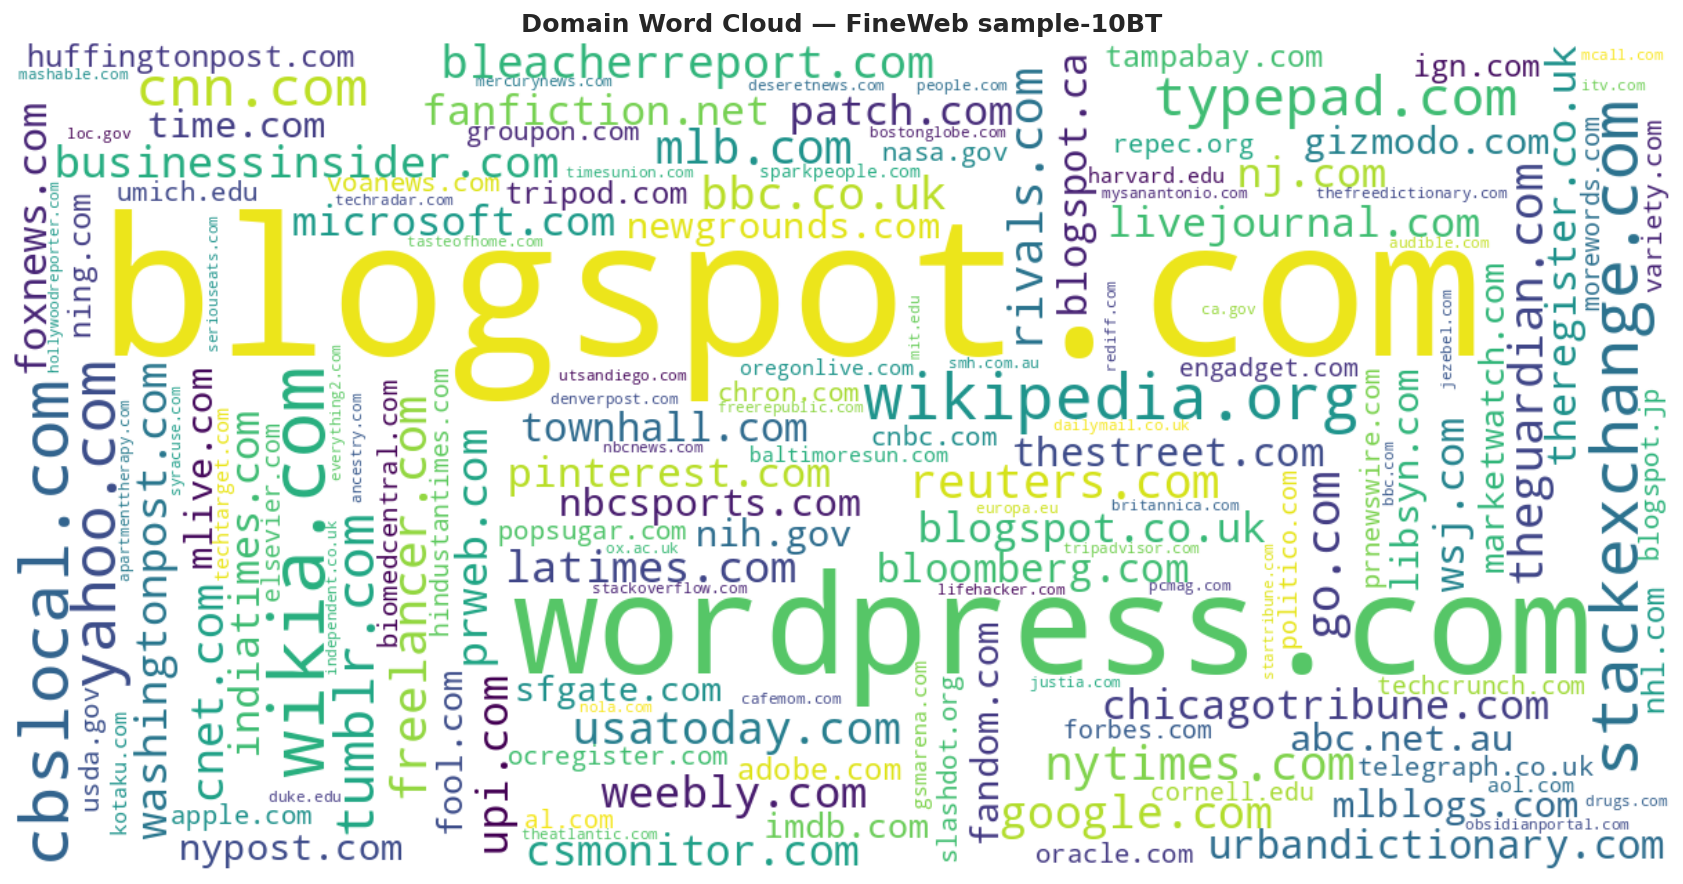

In [24]:
from wordcloud import WordCloud

domain_freq = df_meta["domain"].value_counts().head(200).to_dict()

wc = WordCloud(
    width=1200, height=600, background_color="white",
    colormap="viridis", max_words=150, prefer_horizontal=0.7,
).generate_from_frequencies(domain_freq)

fig, ax = plt.subplots(figsize=(14, 7))
ax.imshow(wc, interpolation="bilinear")
ax.axis("off")
ax.set_title("Domain Word Cloud — FineWeb sample-10BT", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("16_domain_wordcloud.png", bbox_inches="tight")
plt.show()

---
## 20 · Cumulative Token Coverage

How many domains do you need to cover X% of all tokens?

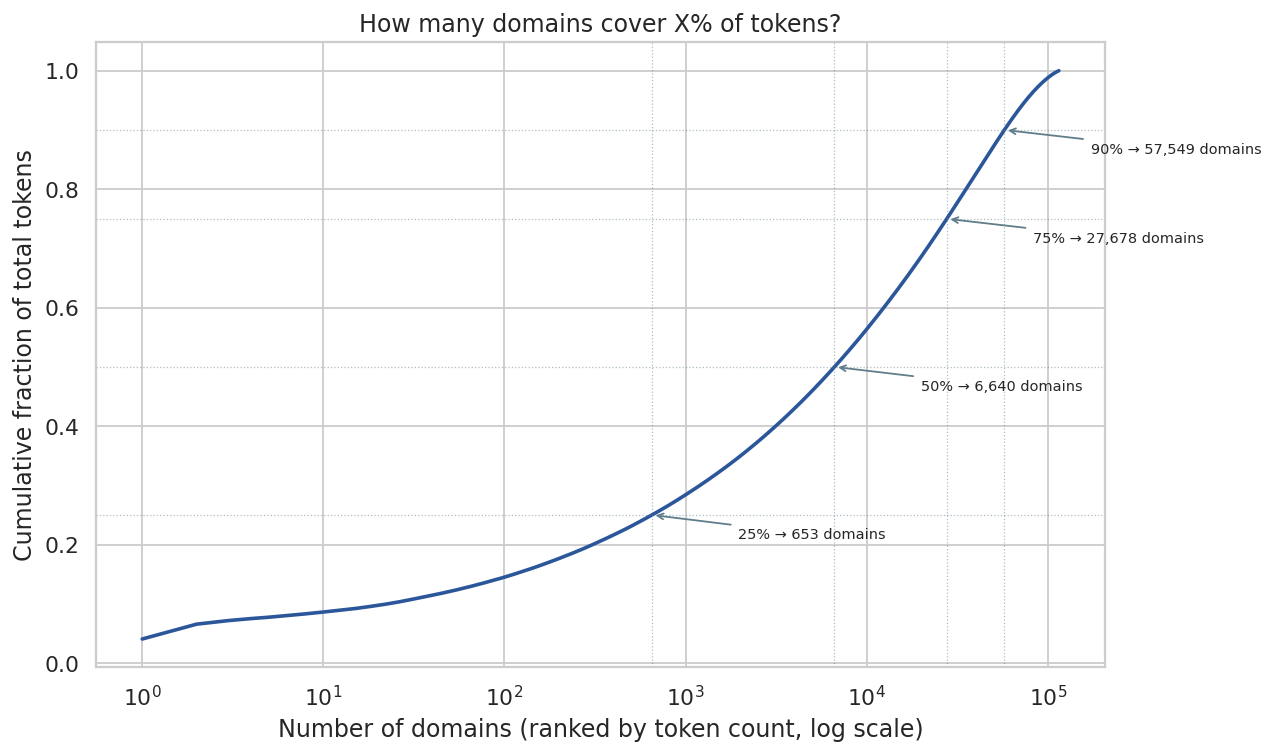

In [25]:
tokens_by_domain = df_meta.groupby("domain")["token_count"].sum().sort_values(ascending=False)
cum_tokens = tokens_by_domain.cumsum() / tokens_by_domain.sum()

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(range(1, len(cum_tokens) + 1), cum_tokens.values,
        color=C["blue"], lw=2)
ax.set_xscale("log")
ax.set_xlabel("Number of domains (ranked by token count, log scale)")
ax.set_ylabel("Cumulative fraction of total tokens")
ax.set_title("How many domains cover X% of tokens?")

for target in [0.25, 0.50, 0.75, 0.90]:
    n_domains = (cum_tokens >= target).idxmax()
    idx = list(cum_tokens.index).index(n_domains) + 1
    ax.axhline(target, color=C["grey"], ls=":", lw=0.7, alpha=0.5)
    ax.axvline(idx, color=C["grey"], ls=":", lw=0.7, alpha=0.5)
    ax.annotate(f"{target:.0%} → {idx:,} domains",
                xy=(idx, target), fontsize=8,
                xytext=(idx * 3, target - 0.04),
                arrowprops=dict(arrowstyle="->", color=C["grey"]))

plt.tight_layout()
plt.savefig("17_cumulative_tokens.png", bbox_inches="tight")
plt.show()

---
## 21 · Language Score vs Crawl Year — Heatmap

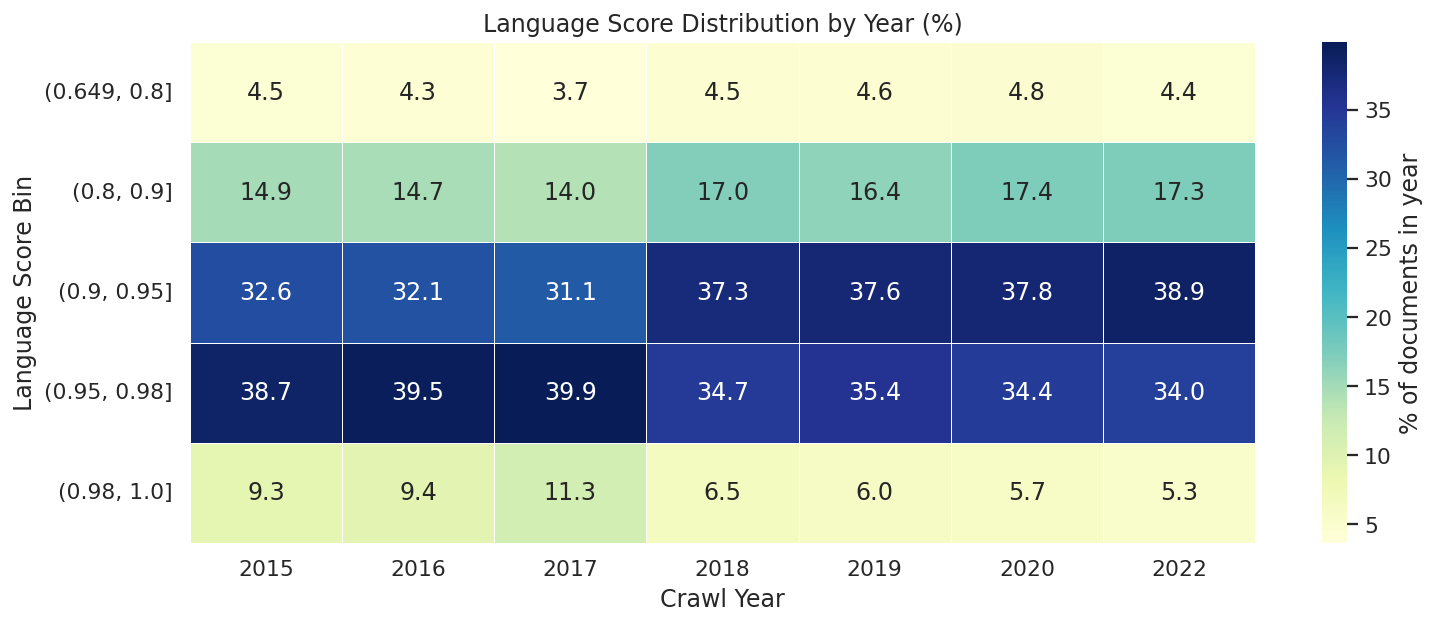

In [26]:
valid = df_meta.dropna(subset=["crawl_year"]).copy()
valid = valid[valid["crawl_year"] >= 2014]
valid["crawl_year"] = valid["crawl_year"].astype(int)
valid["lang_bin"] = pd.cut(
    valid["language_score"],
    bins=[0.65, 0.80, 0.90, 0.95, 0.98, 1.0],
    include_lowest=True,
)

pivot = valid.groupby(["crawl_year", "lang_bin"]).size().unstack(fill_value=0)
# Normalize each year to percentages
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(pivot_pct.T, annot=True, fmt=".1f", cmap="YlGnBu",
            ax=ax, linewidths=0.5,
            cbar_kws={"label": "% of documents in year"})
ax.set_xlabel("Crawl Year")
ax.set_ylabel("Language Score Bin")
ax.set_title("Language Score Distribution by Year (%)")
plt.tight_layout()
plt.savefig("18_lang_year_heatmap.png", bbox_inches="tight")
plt.show()

---
## 22 · Token Count CDF — Comparison Across Eras

Compare the cumulative distribution of document lengths between early and recent crawls.

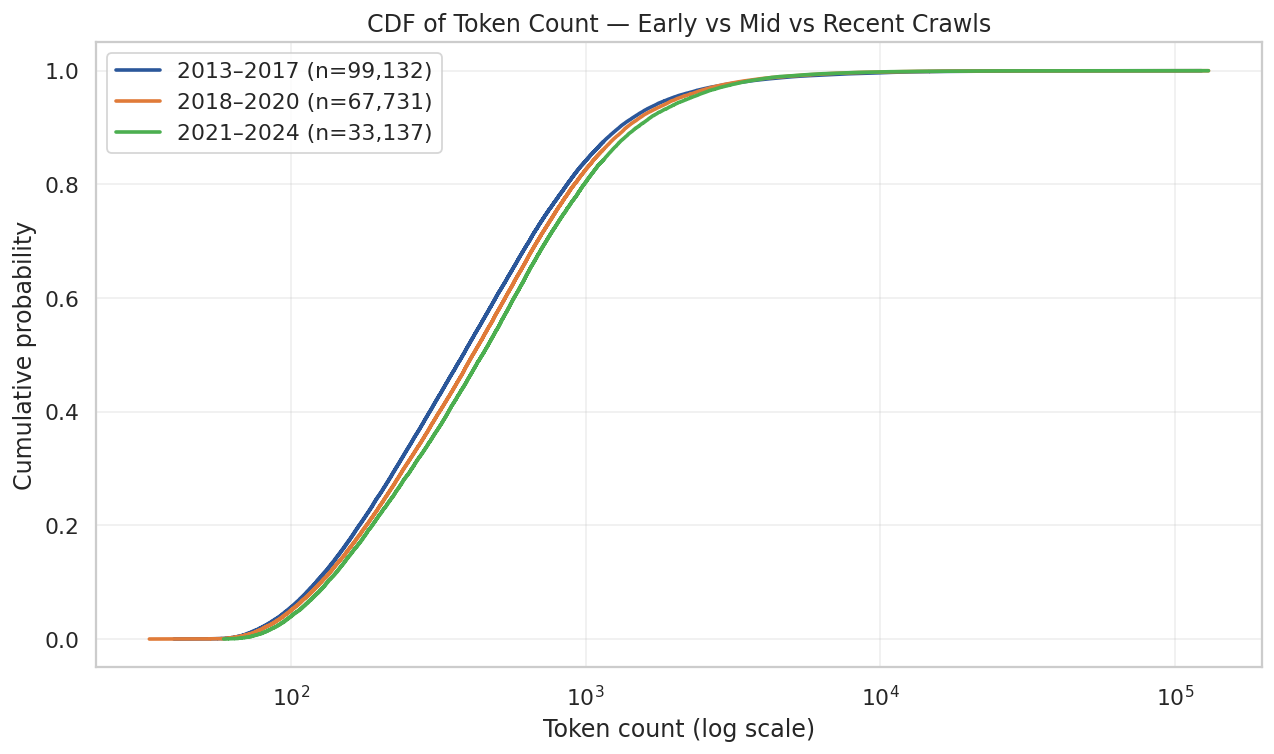

In [27]:
early = df_meta[df_meta["crawl_year"].between(2013, 2017)]["token_count"]
mid   = df_meta[df_meta["crawl_year"].between(2018, 2020)]["token_count"]
late  = df_meta[df_meta["crawl_year"].between(2021, 2025)]["token_count"]

fig, ax = plt.subplots(figsize=(10, 6))
for data, label, color in [
    (early, "2013–2017", C["blue"]),
    (mid,   "2018–2020", C["orange"]),
    (late,  "2021–2024", C["green"]),
]:
    if len(data) > 0:
        sorted_d = np.sort(data.values)
        cdf = np.arange(1, len(sorted_d) + 1) / len(sorted_d)
        ax.plot(sorted_d, cdf, label=f"{label} (n={len(data):,})",
                color=color, lw=2)

ax.set_xscale("log")
ax.set_xlabel("Token count (log scale)")
ax.set_ylabel("Cumulative probability")
ax.set_title("CDF of Token Count — Early vs Mid vs Recent Crawls")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("19_cdf_eras.png", bbox_inches="tight")
plt.show()

---
## 23 · Tokens per Character — A Proxy for Lexical Complexity

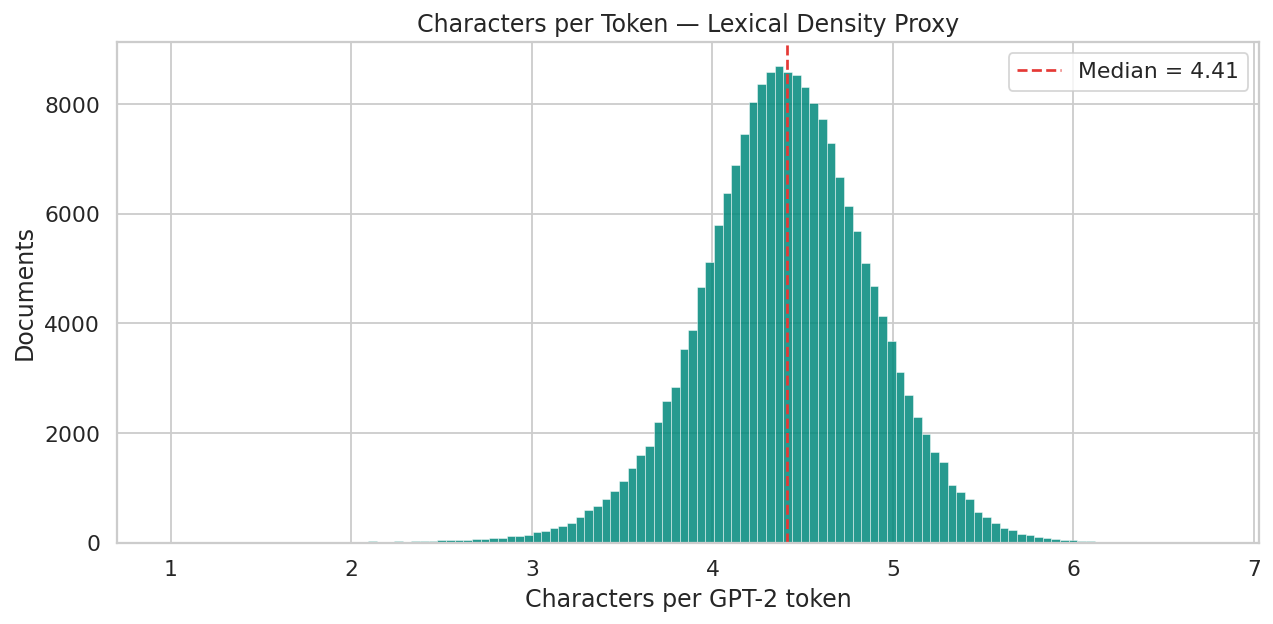

Low chars/token → more subword splitting → more technical/unusual vocabulary
High chars/token → longer common words → more natural prose


In [28]:
df_meta["chars_per_token"] = df_meta["text_length"] / df_meta["token_count"].clip(lower=1)

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df_meta["chars_per_token"].clip(upper=15), bins=120,
        color=C["teal"], alpha=0.85, edgecolor="white", linewidth=0.3)
ax.axvline(df_meta["chars_per_token"].median(), color=C["red"], ls="--", lw=1.5,
           label=f"Median = {df_meta['chars_per_token'].median():.2f}")
ax.set_xlabel("Characters per GPT-2 token")
ax.set_ylabel("Documents")
ax.set_title("Characters per Token — Lexical Density Proxy")
ax.legend()
plt.tight_layout()
plt.savefig("20_chars_per_token.png", bbox_inches="tight")
plt.show()

print("Low chars/token → more subword splitting → more technical/unusual vocabulary")
print("High chars/token → longer common words → more natural prose")

---
## 24 · Summary of Key Findings

| Finding | Detail |
|---------|--------|
| **Token distribution** | Heavily right-skewed (log-normal); median ~200–500 tokens, long tail to >10k |
| **Language scores** | >90% of documents have score ≥ 0.95; filter at 0.65 is very permissive |
| **Domain diversity** | Thousands of unique domains; moderate Gini coefficient; long tail |
| **Temporal coverage** | 2013–2024; recent years dominate; mean doc length is fairly stable |
| **Pipeline funnel** | ~100T raw → ~15T final; biggest drops at text extraction and deduplication |
| **Quality × length** | Short docs have slightly more language-score variance; correlation is weak overall |
| **Chars/token** | Centered around ~4–5, suggesting typical English prose dominates |